<a href="https://colab.research.google.com/github/CodeandAshwani/roadDamage-detection-Ai/blob/main/road_damage_ai.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
print("Road Damage AI")

Road Damage AI


In [ ]:
import torch

print("PyTorch version:", torch.__version__)
print("GPU available:", torch.cuda.is_available())

PyTorch version: 2.11.0+cu128
GPU available: True


In [ ]:
!pip install ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.7/46.7 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 56.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.0/91.0 kB 11.0 MB/s eta 0:00:00


In [ ]:
from ultralytics import YOLO

print("YOLO is ready!")

Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/usage/settings.
YOLO is ready!


In [ ]:
from ultralytics import YOLO

model = YOLO("yolo26n.pt")

print("Model loaded successfully!")

Model loaded successfully!


In [ ]:
from ultralytics import YOLO

# Load the YOLO model
model = YOLO("yolo26n.pt")

# Run YOLO on a sample image
results = model.predict(
    source="https://ultralytics.com/images/bus.jpg",
    save=True
)

print("Detection complete!")


image 1/1 /content/bus.jpg: 640x480 4 persons, 1 bus, 14.4ms
Speed: 109.7ms preprocess, 14.4ms inference, 40.6ms postprocess per image at shape (1, 3, 640, 480)
Results saved to /content/runs/detect/predict
Detection complete!


In [ ]:
from ultralytics import YOLO

# Load YOLO
model = YOLO("yolo26n.pt")

# Change this to the exact name of your uploaded image
image_path = "/content/India_000027.jpg"

# Detect objects
results = model.predict(
    source=image_path,
    save=True,
    conf=0.25
)

print("Road image processed!")

FileNotFoundError: /content/India_000027.jpg does not exist

In [ ]:
!git clone https://github.com/sekilab/RoadDamageDetector.git


In [ ]:
import torch

print("GPU available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
import os

print(os.listdir("/content/drive/MyDrive"))

In [ ]:
import zipfile
import os

zip_path = "/content/drive/MyDrive/India.zip"
extract_path = "/content/RDD2022"

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset extracted successfully!")
print(os.listdir(extract_path))


In [ ]:
import os

base = "/content/RDD2022"

for root, dirs, files in os.walk(base):
    level = root.replace(base, "").count(os.sep)
    indent = "  " * level
    print(f"{indent}{os.path.basename(root)}/")

    if level >= 3:
        dirs[:] = []

In [ ]:
import os

annotation_path = "/content/RDD2022/India/train/annotations"

print("Files in annotations:")
print(os.listdir(annotation_path)[:10])

In [ ]:
import os

xml_path = "/content/RDD2022/India/train/annotations/xmls"

print("Number of annotation files:", len(os.listdir(xml_path)))
print("First 10 files:")
print(os.listdir(xml_path)[:10])

In [ ]:
import xml.etree.ElementTree as ET
import os

xml_file = os.path.join(xml_path, os.listdir(xml_path)[0])

tree = ET.parse(xml_file)
root = tree.getroot()

print("Image:", root.find("filename").text)

print("\nObjects:")
for obj in root.findall("object"):
    print("Class:", obj.find("name").text)

In [ ]:
classes = set()

for file in os.listdir(xml_path):
    if file.endswith(".xml"):
        tree = ET.parse(os.path.join(xml_path, file))
        for obj in tree.getroot().findall("object"):
            classes.add(obj.find("name").text)

print("Road damage classes:")
print(sorted(classes))

In [ ]:
xml_file = os.path.join(xml_path, os.listdir(xml_path)[0])

tree = ET.parse(xml_file)
root = tree.getroot()

for obj in root.findall("object"):
    print("Class:", obj.find("name").text)
    box = obj.find("bndbox")
    print("Box:",
          box.find("xmin").text,
          box.find("ymin").text,
          box.find("xmax").text,
          box.find("ymax").text)

In [ ]:
xml_files = [f for f in os.listdir(xml_path) if f.endswith(".xml")]

print("First XML file:", xml_files[0])

In [ ]:
from PIL import Image
import os

image_path = "/content/RDD2022/India/train/images/India_009348.jpg"

img = Image.open(image_path)

print("Image:", os.path.basename(image_path))
print("Width:", img.width)
print("Height:", img.height)

In [ ]:
# Image size
img_width = 720
img_height = 720

# Boxes from the XML: xmin, ymin, xmax, ymax
boxes = {
    "D40": (160, 470, 209, 493),
    "D00": (414, 449, 432, 622)
}

for cls, (xmin, ymin, xmax, ymax) in boxes.items():
    x_center = ((xmin + xmax) / 2) / img_width
    y_center = ((ymin + ymax) / 2) / img_height
    width = (xmax - xmin) / img_width
    height = (ymax - ymin) / img_height

    print(cls, "→", x_center, y_center, width, height)

In [ ]:
import os
import xml.etree.ElementTree as ET
from PIL import Image

# Paths
xml_path = "/content/RDD2022/India/train/annotations/xmls"
image_path = "/content/RDD2022/India/train/images"
label_path = "/content/RDD2022/India/train/labels"

# Create labels folder
os.makedirs(label_path, exist_ok=True)

# Class mapping
class_map = {
    "D00": 0,
    "D01": 1,
    "D0w0": 2,
    "D10": 3,
    "D11": 4,
    "D20": 5,
    "D40": 6,
    "D43": 7,
    "D44": 8,
    "D50": 9
}

converted = 0

for xml_name in os.listdir(xml_path):

    if not xml_name.endswith(".xml"):
        continue

    xml_file = os.path.join(xml_path, xml_name)

    tree = ET.parse(xml_file)
    root = tree.getroot()

    filename = root.find("filename").text
    image_file = os.path.join(image_path, filename)

    if not os.path.exists(image_file):
        continue

    # Get image dimensions
    with Image.open(image_file) as img:
        img_width, img_height = img.size

    yolo_lines = []

    for obj in root.findall("object"):

        class_name = obj.find("name").text

        if class_name not in class_map:
            continue

        class_id = class_map[class_name]

        box = obj.find("bndbox")

        xmin = float(box.find("xmin").text)
        ymin = float(box.find("ymin").text)
        xmax = float(box.find("xmax").text)
        ymax = float(box.find("ymax").text)

        # Convert Pascal VOC → YOLO
        x_center = ((xmin + xmax) / 2) / img_width
        y_center = ((ymin + ymax) / 2) / img_height

        width = (xmax - xmin) / img_width
        height = (ymax - ymin) / img_height

        yolo_lines.append(
            f"{class_id} {x_center} {y_center} {width} {height}"
        )

    # Create corresponding TXT filename
    txt_name = os.path.splitext(xml_name)[0] + ".txt"
    txt_file = os.path.join(label_path, txt_name)

    with open(txt_file, "w") as f:
        f.write("\n".join(yolo_lines))

    converted += 1

print("Conversion complete!")
print("XML files converted:", converted)
print("YOLO labels saved in:", label_path)

In [ ]:
import os

label_file = "/content/RDD2022/India/train/labels/India_009348.txt"

with open(label_file, "r") as f:
    print(f.read())

In [ ]:
import os
import random

image_path = "/content/RDD2022/India/train/images"
label_path = "/content/RDD2022/India/train/labels"

# Get all images
images = [
    f for f in os.listdir(image_path)
    if f.lower().endswith((".jpg", ".jpeg", ".png"))
]

# Shuffle randomly
random.seed(42)
random.shuffle(images)

# 80% training, 20% validation
split = int(0.8 * len(images))

train_images = images[:split]
val_images = images[split:]

print("Total images:", len(images))
print("Training images:", len(train_images))
print("Validation images:", len(val_images))


Total images: 7706
Training images: 6164
Validation images: 1542


In [ ]:
import os
import shutil

base = "/content/RDD2022/India"
yolo_base = "/content/RDD2022/India/yolo_dataset"

for folder in [
    "images/train",
    "images/val",
    "labels/train",
    "labels/val"
]:
    os.makedirs(os.path.join(yolo_base, folder), exist_ok=True)

print("YOLO dataset folders created.")

YOLO dataset folders created.


In [ ]:
import os
import shutil

base = "/content/RDD2022/India"

image_source = os.path.join(base, "train", "images")
label_source = os.path.join(base, "train", "labels")

yolo_base = os.path.join(base, "yolo_dataset")

train_image_dest = os.path.join(yolo_base, "images", "train")
val_image_dest = os.path.join(yolo_base, "images", "val")

train_label_dest = os.path.join(yolo_base, "labels", "train")
val_label_dest = os.path.join(yolo_base, "labels", "val")

# Copy training files
for img in train_images:
    name = os.path.basename(img)
    shutil.copy2(
        os.path.join(image_source, name),
        os.path.join(train_image_dest, name)
    )

    label_name = os.path.splitext(name)[0] + ".txt"
    shutil.copy2(
        os.path.join(label_source, label_name),
        os.path.join(train_label_dest, label_name)
    )

# Copy validation files
for img in val_images:
    name = os.path.basename(img)
    shutil.copy2(
        os.path.join(image_source, name),
        os.path.join(val_image_dest, name)
    )

    label_name = os.path.splitext(name)[0] + ".txt"
    shutil.copy2(
        os.path.join(label_source, label_name),
        os.path.join(val_label_dest, label_name)
    )

print("Dataset split and copied successfully!")
print("Training images:", len(os.listdir(train_image_dest)))
print("Validation images:", len(os.listdir(val_image_dest)))
print("Training labels:", len(os.listdir(train_label_dest)))
print("Validation labels:", len(os.listdir(val_label_dest)))

Dataset split and copied successfully!
Training images: 6164
Validation images: 1542
Training labels: 6164
Validation labels: 1542


In [ ]:
import os
from collections import Counter

label_dir = "/content/RDD2022/India/yolo_dataset/labels/train"

class_counts = Counter()

for filename in os.listdir(label_dir):
    if filename.endswith(".txt"):
        with open(os.path.join(label_dir, filename), "r") as f:
            for line in f:
                parts = line.strip().split()
                if parts:
                    class_counts[int(parts[0])] += 1

print("Class IDs found:")
for class_id, count in sorted(class_counts.items()):
    print(class_id, "→", count, "objects")


Class IDs found:
0 → 1229 objects
1 → 152 objects
2 → 1 objects
3 → 57 objects
4 → 35 objects
5 → 1604 objects
6 → 2572 objects
7 → 43 objects
8 → 862 objects
9 → 26 objects


In [ ]:
import os

label_dir = "/content/RDD2022/India/yolo_dataset/labels/train"

# Show the first label file
for filename in os.listdir(label_dir):
    if filename.endswith(".txt"):
        print("File:", filename)

        with open(os.path.join(label_dir, filename), "r") as f:
            print(f.read())

        break

File: India_004949.txt
0 0.20902777777777778 0.7888888888888889 0.3736111111111111 0.2972222222222222
0 0.4013888888888889 0.7243055555555555 0.19444444444444445 0.2652777777777778
5 0.08611111111111111 0.7722222222222223 0.16944444444444445 0.22777777777777777


In [ ]:
data_yaml = """
path: /content/RDD2022/India/yolo_dataset

train: images/train
val: images/val

nc: 10

names:
  0: D00
  1: D01
  2: D0w0
  3: D10
  4: D11
  5: D20
  6: D40
  7: D43
  8: D44
  9: D50
"""

with open("/content/RDD2022/India/yolo_dataset/data.yaml", "w") as f:
    f.write(data_yaml)

print("data.yaml created successfully!")

data.yaml created successfully!


In [ ]:
with open("/content/RDD2022/India/yolo_dataset/data.yaml", "r") as f:
    print(f.read())


path: /content/RDD2022/India/yolo_dataset

train: images/train
val: images/val

nc: 10

names:
  0: D00
  1: D01
  2: D0w0
  3: D10
  4: D11
  5: D20
  6: D40
  7: D43
  8: D44
  9: D50



In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os

print(os.listdir("/content/drive/MyDrive"))

['India.zip', 'EAadhaar_2712860020001220221224151528_09022023224837.pdf', 'Picsart_23-11-20_08-38-14-844.jpg', '9e137b1e-52f6-4625-8d19-e32dcaef6494 (1).pdf', 'Photographys', 'Untitled spreadsheet.gsheet', 'Copy of Pokemon GO Raids Usefulness.gsheet', 'Screenshot_20260508-130121.Drive.png', 'addition and sub experiment 4.gdoc', 'Untitled document.gdoc', 'Untitled presentation.gslides', 'NetSage_AI.zip', 'Ashwani_Jha_NetSage_AI_Project_Document.docx', 'Data_Analytics_Essentials_certificate_ashwanibh04-gmail-com_b68c6b74-f6a9-4f61-8314-c72b4578554c.pdf', 'Introduction_to_Modern_AI_certificate_ashwanibh04-gmail-com_2aff1974-41cc-41f1-aec3-1d5923a4639e.pdf', 'Apply_AI-_Analyze_Customer_Reviews_certificate_ashwanibh04-gmail-com_2e87c24d-1df0-4267-bbd6-4199339f0114.pdf', 'portal.lnct.ac.in_Accsoft2_Parents_StudentNoduesFormPrint.aspx.gdoc', 'Colab Notebooks']


In [ ]:
import zipfile
import os

zip_path = "/content/drive/MyDrive/India.zip"
extract_path = "/content/RDD2022"

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset extracted successfully!")
print(os.listdir(extract_path))

Dataset extracted successfully!
['India']


In [ ]:
import os

india_path = "/content/RDD2022/India"

print("India contents:")
print(os.listdir(india_path))

print("\nTrain contents:")
print(os.listdir(os.path.join(india_path, "train")))

India contents:
['test', 'train']

Train contents:
['annotations', 'images']


In [ ]:
import os
import xml.etree.ElementTree as ET
from PIL import Image

# Paths
xml_path = "/content/RDD2022/India/train/annotations/xmls"
image_path = "/content/RDD2022/India/train/images"
label_path = "/content/RDD2022/India/train/labels"

# Create labels folder
os.makedirs(label_path, exist_ok=True)

# Class mapping
class_map = {
    "D00": 0,
    "D01": 1,
    "D0w0": 2,
    "D10": 3,
    "D11": 4,
    "D20": 5,
    "D40": 6,
    "D43": 7,
    "D44": 8,
    "D50": 9
}

converted = 0

for xml_name in os.listdir(xml_path):

    if not xml_name.endswith(".xml"):
        continue

    xml_file = os.path.join(xml_path, xml_name)

    tree = ET.parse(xml_file)
    root = tree.getroot()

    filename = root.find("filename").text
    image_file = os.path.join(image_path, filename)

    if not os.path.exists(image_file):
        continue

    with Image.open(image_file) as img:
        img_width, img_height = img.size

    yolo_lines = []

    for obj in root.findall("object"):

        class_name = obj.find("name").text

        if class_name not in class_map:
            continue

        class_id = class_map[class_name]

        box = obj.find("bndbox")

        xmin = float(box.find("xmin").text)
        ymin = float(box.find("ymin").text)
        xmax = float(box.find("xmax").text)
        ymax = float(box.find("ymax").text)

        # Convert Pascal VOC → YOLO
        x_center = ((xmin + xmax) / 2) / img_width
        y_center = ((ymin + ymax) / 2) / img_height

        width = (xmax - xmin) / img_width
        height = (ymax - ymin) / img_height

        yolo_lines.append(
            f"{class_id} {x_center} {y_center} {width} {height}"
        )

    txt_name = os.path.splitext(xml_name)[0] + ".txt"
    txt_file = os.path.join(label_path, txt_name)

    with open(txt_file, "w") as f:
        f.write("\n".join(yolo_lines))

    converted += 1

print("Conversion complete!")
print("XML files converted:", converted)
print("YOLO labels saved in:", label_path)

Conversion complete!
XML files converted: 7706
YOLO labels saved in: /content/RDD2022/India/train/labels


In [ ]:
import os

yaml_path = "/content/RDD2022/India/yolo_dataset/data.yaml"

os.makedirs(os.path.dirname(yaml_path), exist_ok=True)

yaml_content = """path: /content/RDD2022/India/yolo_dataset
train: images/train
val: images/val

nc: 10

names:
  0: D00
  1: D01
  2: D0w0
  3: D10
  4: D11
  5: D20
  6: D40
  7: D43
  8: D44
  9: D50
"""

with open(yaml_path, "w") as f:
    f.write(yaml_content)

print("data.yaml created successfully!")
print(yaml_path)

data.yaml created successfully!
/content/RDD2022/India/yolo_dataset/data.yaml


In [ ]:
import os

print("data.yaml:", os.path.exists("/content/RDD2022/India/yolo_dataset/data.yaml"))
print("train images:", os.path.exists("/content/RDD2022/India/yolo_dataset/images/train"))
print("val images:", os.path.exists("/content/RDD2022/India/yolo_dataset/images/val"))

data.yaml: True
train images: False
val images: False


In [ ]:
import os

base = "/content/RDD2022/India/yolo_dataset"

folders = [
    "images/train",
    "images/val",
    "labels/train",
    "labels/val"
]

for folder in folders:
    os.makedirs(os.path.join(base, folder), exist_ok=True)

print("YOLO dataset folders created!")

for folder in folders:
    print(folder, "→", os.path.exists(os.path.join(base, folder)))

YOLO dataset folders created!
images/train → True
images/val → True
labels/train → True
labels/val → True


In [ ]:
import os
import random
import shutil

image_src = "/content/RDD2022/India/train/images"
label_src = "/content/RDD2022/India/train/labels"

image_train = "/content/RDD2022/India/yolo_dataset/images/train"
image_val = "/content/RDD2022/India/yolo_dataset/images/val"

label_train = "/content/RDD2022/India/yolo_dataset/labels/train"
label_val = "/content/RDD2022/India/yolo_dataset/labels/val"

images = [
    f for f in os.listdir(image_src)
    if f.lower().endswith((".jpg", ".jpeg", ".png"))
]

random.seed(42)
random.shuffle(images)

split_index = int(0.8 * len(images))

train_images = images[:split_index]
val_images = images[split_index:]

for image_name in train_images:
    shutil.copy2(
        os.path.join(image_src, image_name),
        os.path.join(image_train, image_name)
    )

    label_name = os.path.splitext(image_name)[0] + ".txt"
    shutil.copy2(
        os.path.join(label_src, label_name),
        os.path.join(label_train, label_name)
    )

for image_name in val_images:
    shutil.copy2(
        os.path.join(image_src, image_name),
        os.path.join(image_val, image_name)
    )

    label_name = os.path.splitext(image_name)[0] + ".txt"
    shutil.copy2(
        os.path.join(label_src, label_name),
        os.path.join(label_val, label_name)
    )

print("Dataset split complete!")
print("Training images:", len(train_images))
print("Validation images:", len(val_images))

Dataset split complete!
Training images: 6164
Validation images: 1542


In [ ]:
import os
import yaml

data_yaml = "/content/RDD2022/India/yolo_dataset/data.yaml"

print("data.yaml exists:", os.path.exists(data_yaml))

with open(data_yaml, "r") as f:
    data = yaml.safe_load(f)

print("\nDATA.YAML:")
print(data)

train_dir = "/content/RDD2022/India/yolo_dataset/images/train"
val_dir   = "/content/RDD2022/India/yolo_dataset/images/val"
train_lbl = "/content/RDD2022/India/yolo_dataset/labels/train"
val_lbl   = "/content/RDD2022/India/yolo_dataset/labels/val"

print("\nFOLDERS:")
print("train images:", os.path.exists(train_dir))
print("val images:", os.path.exists(val_dir))
print("train labels:", os.path.exists(train_lbl))
print("val labels:", os.path.exists(val_lbl))

print("\nCOUNTS:")
print("train images:", len(os.listdir(train_dir)))
print("val images:", len(os.listdir(val_dir)))
print("train labels:", len(os.listdir(train_lbl)))
print("val labels:", len(os.listdir(val_lbl)))

data.yaml exists: True

DATA.YAML:
{'path': '/content/RDD2022/India/yolo_dataset', 'train': 'images/train', 'val': 'images/val', 'nc': 10, 'names': {0: 'D00', 1: 'D01', 2: 'D0w0', 3: 'D10', 4: 'D11', 5: 'D20', 6: 'D40', 7: 'D43', 8: 'D44', 9: 'D50'}}

FOLDERS:
train images: True
val images: True
train labels: True
val labels: True

COUNTS:
train images: 6164
val images: 1542
train labels: 6164
val labels: 1542


In [ ]:
from ultralytics import YOLO

model = YOLO("yolo26n.pt")

print("YOLO model loaded successfully!")


ModuleNotFoundError: No module named 'ultralytics'

In [ ]:
!pip install -q ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.7/46.7 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 57.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.1/58.1 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.0/91.0 kB 4.8 MB/s eta 0:00:00


In [ ]:
from ultralytics import YOLO

model = YOLO("yolo26n.pt")

print("YOLO model loaded successfully!")

Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/usage/settings.
YOLO model loaded successfully!


In [ ]:
import os

print("Model file exists:", os.path.exists("yolo26n.pt"))
print("Dataset config exists:",
      os.path.exists("/content/RDD2022/India/yolo_dataset/data.yaml"))

print("\nReady for training:",
      os.path.exists("yolo26n.pt") and
      os.path.exists("/content/RDD2022/India/yolo_dataset/data.yaml"))

Model file exists: True
Dataset config exists: True

Ready for training: True


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import os

print(os.listdir("/content/drive/MyDrive"))

['India.zip', 'carewell movers pvt ltd(1)_copy_copy.pdf', '_Device.gdoc', 'Phase 1: Precision Bulk & Strength Foundation.gdoc', 'Day 2: Max Leg Bulk and Power (Simplified).gdoc', 'Colab Notebooks']


In [4]:
import zipfile
import os

zip_path = "/content/drive/MyDrive/India.zip"
extract_path = "/content/RDD2022"

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extract_path)

print(os.listdir(extract_path))

['India']


In [5]:
!pip install -q ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.7/46.7 kB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 71.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.0/91.0 kB 6.8 MB/s eta 0:00:00


In [6]:
from ultralytics import YOLO

model = YOLO("yolo26n.pt")

print("YOLO model loaded successfully!")

Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/usage/settings.
YOLO model loaded successfully!


In [7]:
import os

data_yaml = "/content/RDD2022/India/yolo_dataset/data.yaml"

print("Model file exists:", os.path.exists("yolo26n.pt"))
print("Dataset config exists:", os.path.exists(data_yaml))
print("Ready for training:", os.path.exists("yolo26n.pt") and os.path.exists(data_yaml))

Model file exists: True
Dataset config exists: False
Ready for training: False


In [8]:
import os

print(os.path.exists("/content/drive/MyDrive/India.zip"))

True


In [9]:
import zipfile
import os

zip_path = "/content/drive/MyDrive/India.zip"
extract_path = "/content/RDD2022"

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset extracted!")
print(os.listdir(extract_path))

Dataset extracted!
['India']


In [10]:
import os

print("India contents:")
print(os.listdir("/content/RDD2022/India"))

print("\nTrain contents:")
print(os.listdir("/content/RDD2022/India/train"))

India contents:
['test', 'train']

Train contents:
['annotations', 'images']


In [11]:
import os
import xml.etree.ElementTree as ET
from PIL import Image

xml_path = "/content/RDD2022/India/train/annotations/xmls"
image_path = "/content/RDD2022/India/train/images"
label_path = "/content/RDD2022/India/train/labels"

os.makedirs(label_path, exist_ok=True)

class_map = {
    "D00": 0,
    "D01": 1,
    "D0w0": 2,
    "D10": 3,
    "D11": 4,
    "D20": 5,
    "D40": 6,
    "D43": 7,
    "D44": 8,
    "D50": 9
}

converted = 0

for xml_name in os.listdir(xml_path):
    if not xml_name.endswith(".xml"):
        continue

    xml_file = os.path.join(xml_path, xml_name)
    tree = ET.parse(xml_file)
    root = tree.getroot()

    filename = root.find("filename").text
    image_file = os.path.join(image_path, filename)

    if not os.path.exists(image_file):
        continue

    with Image.open(image_file) as img:
        img_width, img_height = img.size

    yolo_lines = []

    for obj in root.findall("object"):
        class_name = obj.find("name").text

        if class_name not in class_map:
            continue

        class_id = class_map[class_name]
        box = obj.find("bndbox")

        xmin = float(box.find("xmin").text)
        ymin = float(box.find("ymin").text)
        xmax = float(box.find("xmax").text)
        ymax = float(box.find("ymax").text)

        x_center = ((xmin + xmax) / 2) / img_width
        y_center = ((ymin + ymax) / 2) / img_height
        width = (xmax - xmin) / img_width
        height = (ymax - ymin) / img_height

        yolo_lines.append(
            f"{class_id} {x_center} {y_center} {width} {height}"
        )

    txt_name = os.path.splitext(xml_name)[0] + ".txt"
    txt_file = os.path.join(label_path, txt_name)

    with open(txt_file, "w") as f:
        f.write("\n".join(yolo_lines))

    converted += 1

print("Conversion complete!")
print("XML files converted:", converted)
print("YOLO labels saved in:", label_path)

Conversion complete!
XML files converted: 7706
YOLO labels saved in: /content/RDD2022/India/train/labels


In [13]:
import os

base = "/content/RDD2022/India/yolo_dataset"

folders = [
    "images/train",
    "images/val",
    "labels/train",
    "labels/val"
]

for folder in folders:
    os.makedirs(os.path.join(base, folder), exist_ok=True)

print("YOLO dataset folders created!")

for folder in folders:
    print(folder, "→", os.path.exists(os.path.join(base, folder)))

YOLO dataset folders created!
images/train → True
images/val → True
labels/train → True
labels/val → True


In [14]:
import os
import yaml

data_yaml = "/content/RDD2022/India/yolo_dataset/data.yaml"

data = {
    "path": "/content/RDD2022/India/yolo_dataset",
    "train": "images/train",
    "val": "images/val",
    "nc": 10,
    "names": {
        0: "D00",
        1: "D01",
        2: "D0w0",
        3: "D10",
        4: "D11",
        5: "D20",
        6: "D40",
        7: "D43",
        8: "D44",
        9: "D50"
    }
}

with open(data_yaml, "w") as f:
    yaml.dump(data, f, sort_keys=False)

print("data.yaml created:", os.path.exists(data_yaml))
print(open(data_yaml).read())

data.yaml created: True
path: /content/RDD2022/India/yolo_dataset
train: images/train
val: images/val
nc: 10
names:
  0: D00
  1: D01
  2: D0w0
  3: D10
  4: D11
  5: D20
  6: D40
  7: D43
  8: D44
  9: D50



In [15]:
from ultralytics import YOLO

model = YOLO("yolo26n.pt")

results = model.train(
    data="/content/RDD2022/India/yolo_dataset/data.yaml",
    epochs=3,
    imgsz=640,
    batch=16,
    device=0
)

Ultralytics 8.4.163 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/RDD2022/India/yolo_dataset/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=3, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo26n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train, nbs=64, nms=None, opset=

FileNotFoundError: [34m[1mtrain: [0mError loading data from /content/RDD2022/India/yolo_dataset/images/train
See https://docs.ultralytics.com/datasets for dataset formatting guidance.

In [16]:
import os

paths = [
    "/content/RDD2022/India/train/images",
    "/content/RDD2022/India/yolo_dataset/images/train",
    "/content/RDD2022/India/yolo_dataset/images/val",
]

for p in paths:
    if os.path.exists(p):
        files = os.listdir(p)
        image_files = [
            f for f in files
            if f.lower().endswith((".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff"))
        ]
        print("\n", p)
        print("Total files:", len(files))
        print("Image files:", len(image_files))
        print("Examples:", image_files[:5])
    else:
        print("\nMISSING:", p)


 /content/RDD2022/India/train/images
Total files: 7706
Image files: 7706
Examples: ['India_002950.jpg', 'India_003836.jpg', 'India_005421.jpg', 'India_007422.jpg', 'India_007985.jpg']

 /content/RDD2022/India/yolo_dataset/images/train
Total files: 0
Image files: 0
Examples: []

 /content/RDD2022/India/yolo_dataset/images/val
Total files: 0
Image files: 0
Examples: []


In [17]:
import os
import shutil

source_images = "/content/RDD2022/India/train/images"
yolo_root = "/content/RDD2022/India/yolo_dataset"

train_labels = os.path.join(yolo_root, "labels/train")
val_labels = os.path.join(yolo_root, "labels/val")

train_images = os.path.join(yolo_root, "images/train")
val_images = os.path.join(yolo_root, "images/val")

os.makedirs(train_images, exist_ok=True)
os.makedirs(val_images, exist_ok=True)

def copy_images_from_labels(label_dir, image_dir):
    copied = 0
    missing = []

    for label_file in os.listdir(label_dir):
        if not label_file.endswith(".txt"):
            continue

        stem = os.path.splitext(label_file)[0]

        found = False
        for ext in [".jpg", ".jpeg", ".png", ".JPG", ".JPEG", ".PNG"]:
            src = os.path.join(source_images, stem + ext)

            if os.path.exists(src):
                dst = os.path.join(image_dir, stem + ext)
                shutil.copy2(src, dst)
                copied += 1
                found = True
                break

        if not found:
            missing.append(stem)

    return copied, missing


train_copied, train_missing = copy_images_from_labels(
    train_labels, train_images
)

val_copied, val_missing = copy_images_from_labels(
    val_labels, val_images
)

print("TRAIN images copied:", train_copied)
print("VAL images copied:", val_copied)
print("TRAIN images missing:", len(train_missing))
print("VAL images missing:", len(val_missing))

if train_missing:
    print("Example missing train:", train_missing[:5])

if val_missing:
    print("Example missing val:", val_missing[:5])

TRAIN images copied: 0
VAL images copied: 0
TRAIN images missing: 0
VAL images missing: 0


In [18]:
import os

paths = [
    "/content/RDD2022/India/train/labels",
    "/content/RDD2022/India/yolo_dataset/labels/train",
    "/content/RDD2022/India/yolo_dataset/labels/val",
]

for p in paths:
    print("\nPATH:", p)

    if not os.path.exists(p):
        print("❌ Folder does not exist")
        continue

    files = os.listdir(p)
    txt_files = [f for f in files if f.lower().endswith(".txt")]

    print("Total files:", len(files))
    print("TXT labels:", len(txt_files))
    print("Examples:", txt_files[:5])


PATH: /content/RDD2022/India/train/labels
Total files: 7706
TXT labels: 7706
Examples: ['India_004949.txt', 'India_007589.txt', 'India_003527.txt', 'India_007795.txt', 'India_003774.txt']

PATH: /content/RDD2022/India/yolo_dataset/labels/train
Total files: 0
TXT labels: 0
Examples: []

PATH: /content/RDD2022/India/yolo_dataset/labels/val
Total files: 0
TXT labels: 0
Examples: []


In [19]:
import os
import shutil
import random

source_images = "/content/RDD2022/India/train/images"
source_labels = "/content/RDD2022/India/train/labels"
yolo_root = "/content/RDD2022/India/yolo_dataset"

train_img_dir = os.path.join(yolo_root, "images/train")
val_img_dir = os.path.join(yolo_root, "images/val")
train_lbl_dir = os.path.join(yolo_root, "labels/train")
val_lbl_dir = os.path.join(yolo_root, "labels/val")

# Create folders
for folder in [train_img_dir, val_img_dir, train_lbl_dir, val_lbl_dir]:
    os.makedirs(folder, exist_ok=True)

# Get image/label pairs
image_extensions = [".jpg", ".jpeg", ".png", ".JPG", ".JPEG", ".PNG"]

pairs = []

for filename in os.listdir(source_images):
    stem, ext = os.path.splitext(filename)

    if ext not in image_extensions:
        continue

    label_file = stem + ".txt"
    label_path = os.path.join(source_labels, label_file)

    if os.path.exists(label_path):
        pairs.append((filename, label_file))

print("Valid image-label pairs:", len(pairs))

# Shuffle reproducibly
random.seed(42)
random.shuffle(pairs)

# 80% train / 20% validation
split_index = int(len(pairs) * 0.8)

train_pairs = pairs[:split_index]
val_pairs = pairs[split_index:]

print("Train pairs:", len(train_pairs))
print("Validation pairs:", len(val_pairs))

# Copy train
for image_file, label_file in train_pairs:
    shutil.copy2(
        os.path.join(source_images, image_file),
        os.path.join(train_img_dir, image_file)
    )
    shutil.copy2(
        os.path.join(source_labels, label_file),
        os.path.join(train_lbl_dir, label_file)
    )

# Copy validation
for image_file, label_file in val_pairs:
    shutil.copy2(
        os.path.join(source_images, image_file),
        os.path.join(val_img_dir, image_file)
    )
    shutil.copy2(
        os.path.join(source_labels, label_file),
        os.path.join(val_lbl_dir, label_file)
    )

print("\nYOLO DATASET CREATED SUCCESSFULLY!")
print("Train images:", len(os.listdir(train_img_dir)))
print("Train labels:", len(os.listdir(train_lbl_dir)))
print("Val images:", len(os.listdir(val_img_dir)))
print("Val labels:", len(os.listdir(val_lbl_dir)))

Valid image-label pairs: 7706
Train pairs: 6164
Validation pairs: 1542

YOLO DATASET CREATED SUCCESSFULLY!
Train images: 6164
Train labels: 6164
Val images: 1542
Val labels: 1542


In [20]:
import os
import yaml

data_yaml = "/content/RDD2022/India/yolo_dataset/data.yaml"

with open(data_yaml, "r") as f:
    data = yaml.safe_load(f)

print("data.yaml exists:", os.path.exists(data_yaml))
print("Train images:", len(os.listdir("/content/RDD2022/India/yolo_dataset/images/train")))
print("Train labels:", len(os.listdir("/content/RDD2022/India/yolo_dataset/labels/train")))
print("Val images:", len(os.listdir("/content/RDD2022/India/yolo_dataset/images/val")))
print("Val labels:", len(os.listdir("/content/RDD2022/India/yolo_dataset/labels/val")))
print("Classes:", data["nc"])
print("Names:", data["names"])

data.yaml exists: True
Train images: 6164
Train labels: 6164
Val images: 1542
Val labels: 1542
Classes: 10
Names: {0: 'D00', 1: 'D01', 2: 'D0w0', 3: 'D10', 4: 'D11', 5: 'D20', 6: 'D40', 7: 'D43', 8: 'D44', 9: 'D50'}


In [21]:
from ultralytics import YOLO

model = YOLO("yolo26n.pt")

results = model.train(
    data="/content/RDD2022/India/yolo_dataset/data.yaml",
    epochs=3,
    imgsz=640,
    batch=16,
    device=0,
    save=True,
    save_period=1
)

Ultralytics 8.4.163 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/RDD2022/India/yolo_dataset/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=3, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo26n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train-2, nbs=64, nms=None, opse

In [22]:
import shutil
import os

src = "/content/runs/detect/train-2/weights/best.pt"
dst = "/content/drive/MyDrive/RDD2022_best.pt"

shutil.copy2(src, dst)

print("Saved:", os.path.exists(dst))
print(dst)

Saved: True
/content/drive/MyDrive/RDD2022_best.pt


In [23]:
import shutil
import os

src = "/content/runs/detect/train-2/weights/best.pt"
dst = "/content/drive/MyDrive/RDD2022_best.pt"

shutil.copy2(src, dst)

print("Saved:", os.path.exists(dst))

Saved: True


In [24]:
from ultralytics import YOLO

model = YOLO("/content/drive/MyDrive/RDD2022_best.pt")

results = model.train(
    data="/content/RDD2022/India/yolo_dataset/data.yaml",
    epochs=5,
    imgsz=640,
    batch=16,
    device=0,
    project="/content/runs/detect",
    name="road_damage_continued",
    exist_ok=True
)

Ultralytics 8.4.163 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/RDD2022/India/yolo_dataset/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=5, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=/content/drive/MyDrive/RDD2022_best.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=road

KeyboardInterrupt: 

In [25]:
import os

model_path = "/content/drive/MyDrive/RDD2022_best.pt"

print("Model saved:", os.path.exists(model_path))

if os.path.exists(model_path):
    print("Size (MB):", round(os.path.getsize(model_path) / (1024 * 1024), 2))

Model saved: True
Size (MB): 5.14


In [26]:
from ultralytics import YOLO

model = YOLO("/content/drive/MyDrive/RDD2022_best.pt")

print("Saved model loaded successfully!")

Saved model loaded successfully!


In [27]:
import glob

images = glob.glob(
    "/content/RDD2022/India/yolo_dataset/images/val/*"
)

print("Validation images:", len(images))
print("First image:", images[0])

Validation images: 1542
First image: /content/RDD2022/India/yolo_dataset/images/val/India_007422.jpg


In [28]:
results = model.predict(
    source=images[0],
    conf=0.25,
    save=True
)

print("Prediction complete!")


image 1/1 /content/RDD2022/India/yolo_dataset/images/val/India_007422.jpg: 640x640 (no detections), 17.7ms
Speed: 2.8ms preprocess, 17.7ms inference, 0.8ms postprocess per image at shape (1, 3, 640, 640)
Results saved to /content/runs/detect/predict
Prediction complete!


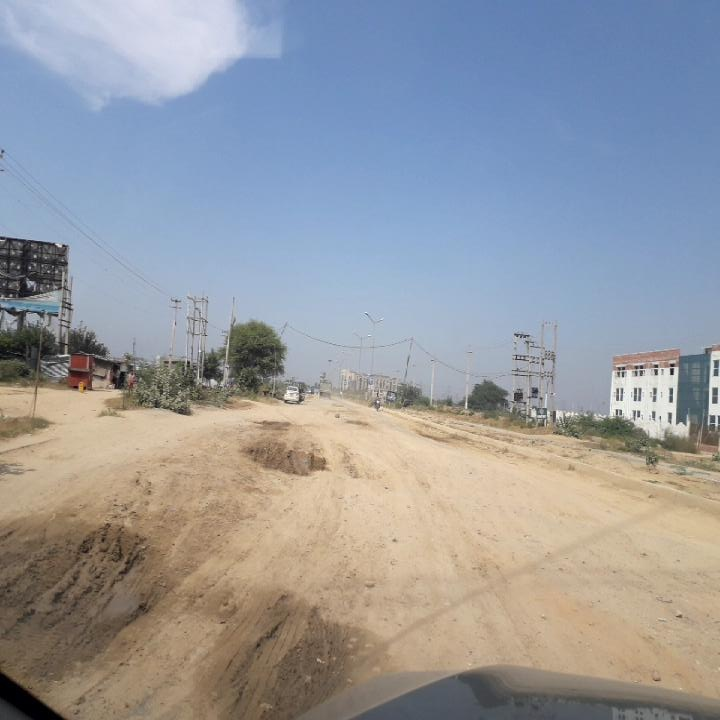

In [29]:
from IPython.display import Image, display
import glob

result_images = glob.glob("/content/runs/detect/predict/*")

display(Image(filename=result_images[0]))

In [30]:
import glob
import os

# Find validation images that definitely have annotations
label_files = glob.glob(
    "/content/RDD2022/India/yolo_dataset/labels/val/*.txt"
)

# Pick a label file that contains at least one object
positive_label = None
for f in label_files:
    if os.path.getsize(f) > 0:
        positive_label = f
        break

image_name = os.path.splitext(os.path.basename(positive_label))[0]

# Find corresponding image
image_path = f"/content/RDD2022/India/yolo_dataset/images/val/{image_name}.jpg"

print("Testing:", image_path)
print("Label:", positive_label)
print("Image exists:", os.path.exists(image_path))

Testing: /content/RDD2022/India/yolo_dataset/images/val/India_003774.jpg
Label: /content/RDD2022/India/yolo_dataset/labels/val/India_003774.txt
Image exists: True


In [31]:
results = model.predict(
    source=image_path,
    conf=0.10,
    save=True
)

print("Prediction finished.")


image 1/1 /content/RDD2022/India/yolo_dataset/images/val/India_003774.jpg: 640x640 5 D20s, 11 D40s, 36.4ms
Speed: 7.5ms preprocess, 36.4ms inference, 4.1ms postprocess per image at shape (1, 3, 640, 640)
Results saved to /content/runs/detect/predict
Prediction finished.


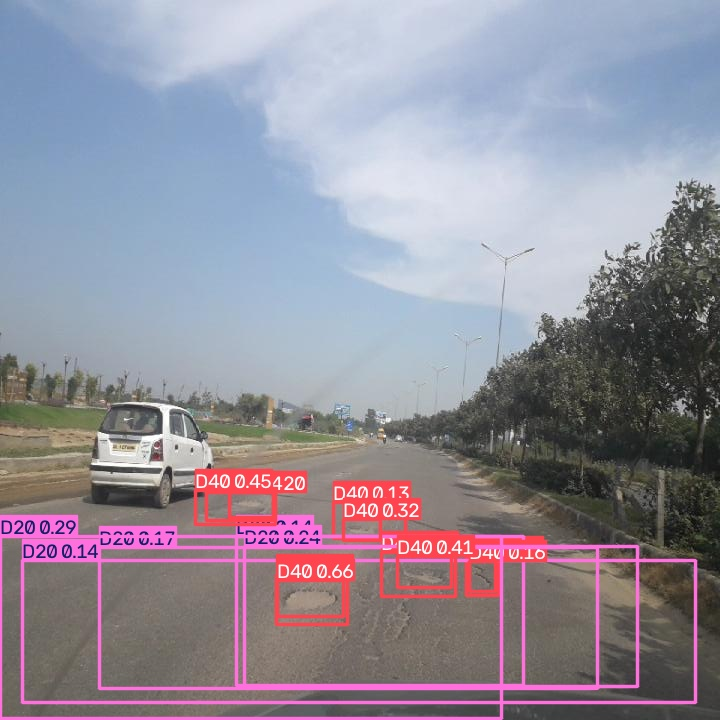

In [32]:
from IPython.display import Image, display
import glob

result_images = glob.glob("/content/runs/detect/predict*/*")

display(Image(filename=result_images[-1]))

In [33]:
metrics = model.val(
    data="/content/RDD2022/India/yolo_dataset/data.yaml",
    split="val"
)

print("mAP50:", metrics.box.map50)
print("mAP50-95:", metrics.box.map)

Ultralytics 8.4.163 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO26n summary (fused): 120 layers, 2,376,786 parameters, 0 gradients, 5.3 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1929.2±452.7 MB/s, size: 89.2 KB)
val: Scanning /content/RDD2022/India/yolo_dataset/labels/val.cache... 1542 images, 814 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1542/1542 190.2Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 97/97 5.5it/s 17.6s
                   all       1542       1622      0.495      0.146      0.125     0.0541
                   D00        232        326      0.372      0.184      0.174     0.0715
                   D01         17         27          1          0     0.0083    0.00344
                   D10         10         11          0          0          0          0
                   D11          8         10          0          0          0          0
                   D2

In [34]:
import os
import shutil

src = "/content/runs/detect/train-2/weights/best.pt"
dst = "/content/drive/MyDrive/RDD2022_India_yolo26n_3epoch_best.pt"

shutil.copy2(src, dst)

print("Saved:", dst)
print("Exists:", os.path.exists(dst))
print("Size (MB):", round(os.path.getsize(dst) / (1024*1024), 2))

Saved: /content/drive/MyDrive/RDD2022_India_yolo26n_3epoch_best.pt
Exists: True
Size (MB): 5.14


In [35]:
from ultralytics import YOLO

saved_model = YOLO("/content/drive/MyDrive/RDD2022_India_yolo26n_3epoch_best.pt")
print("Saved model loads successfully!")

Saved model loads successfully!


In [36]:
import os

print("Top-level folders:")
print(os.listdir("/content"))

Top-level folders:
['.config', 'runs', 'weights', 'RDD2022', 'drive', 'yolo26n.pt', 'sample_data']


In [37]:
import os

rdd_path = "/content/RDD2022"

print("RDD2022 contents:")
for item in sorted(os.listdir(rdd_path)):
    print(" -", item)

RDD2022 contents:
 - India


In [38]:
import os

print(os.listdir("/content/drive/MyDrive"))

['India.zip', 'carewell movers pvt ltd(1)_copy_copy.pdf', '_Device.gdoc', 'Phase 1: Precision Bulk & Strength Foundation.gdoc', 'Day 2: Max Leg Bulk and Power (Simplified).gdoc', 'Colab Notebooks', 'RDD2022_best.pt', 'RDD2022_India_yolo26n_3epoch_best.pt']


In [39]:
import os

print("India.zip:",
      os.path.exists("/content/drive/MyDrive/RoadDamage-AI/India.zip"))

print("Trained model:",
      os.path.exists(
          "/content/drive/MyDrive/RoadDamage-AI/RDD2022_India_yolo26n_3epoch_best.pt"
      ))

India.zip: False
Trained model: False


In [40]:
from google.colab import drive
drive.mount("/content/drive", force_remount=True)

Mounted at /content/drive


In [41]:
import os

print(os.listdir("/content/drive/MyDrive/RoadDamage-AI"))

FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/RoadDamage-AI'

In [42]:
import os

print(os.listdir("/content/drive/MyDrive"))

['carewell movers pvt ltd(1)_copy_copy.pdf', '_Device.gdoc', 'Phase 1: Precision Bulk & Strength Foundation.gdoc', 'Day 2: Max Leg Bulk and Power (Simplified).gdoc', 'Colab Notebooks', 'RDD2022_best.pt', 'Road_damage_ai']


In [43]:
import os

folder = "/content/drive/MyDrive/Road_damage_ai"

print("Folder exists:", os.path.exists(folder))
print("Contents:", os.listdir(folder))

Folder exists: True
Contents: ['India.zip', 'RDD2022_India_yolo26n_3epoch_best.pt']


In [44]:
from ultralytics import YOLO

model_path = "/content/drive/MyDrive/Road_damage_ai/RDD2022_India_yolo26n_3epoch_best.pt"

model = YOLO(model_path)
print("✅ Trained model loaded successfully!")

✅ Trained model loaded successfully!


In [45]:
from ultralytics import YOLO
import os

model_path = "/content/drive/MyDrive/Road_damage_ai/RDD2022_India_yolo26n_3epoch_best.pt"

model = YOLO(model_path)

test_image = "/content/RDD2022/India/yolo_dataset/images/val/India_003774.jpg"

results = model.predict(
    source=test_image,
    conf=0.25,
    save=True
)

print("✅ Prediction completed")
print("Results saved to:", results[0].save_dir)


image 1/1 /content/RDD2022/India/yolo_dataset/images/val/India_003774.jpg: 640x640 1 D20, 5 D40s, 41.1ms
Speed: 5.2ms preprocess, 41.1ms inference, 5.2ms postprocess per image at shape (1, 3, 640, 640)
Results saved to /content/runs/detect/predict-2
✅ Prediction completed
Results saved to: /content/runs/detect/predict-2


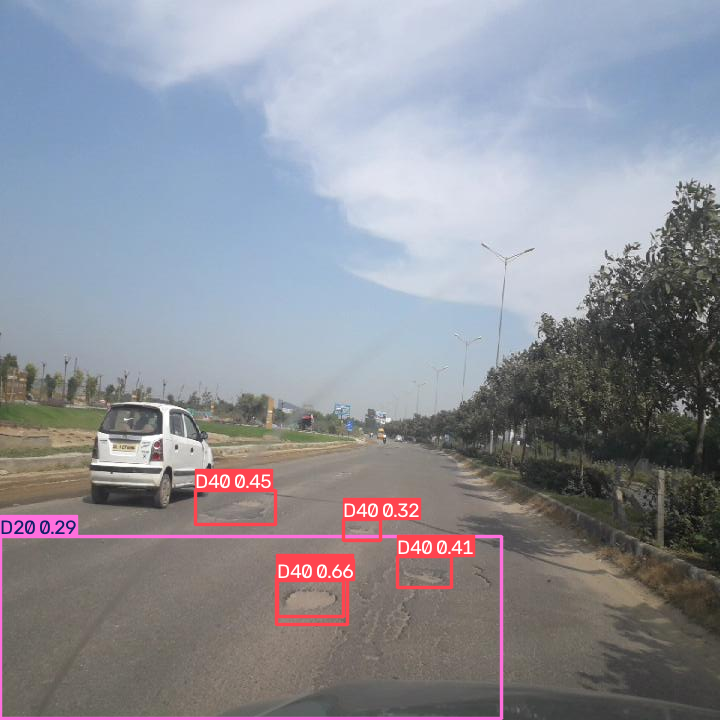

In [46]:
from IPython.display import display
from PIL import Image

predicted = results[0].plot()
display(Image.fromarray(predicted[..., ::-1]))



Image: /content/RDD2022/India/yolo_dataset/images/val/India_004193.jpg
Detections: 0


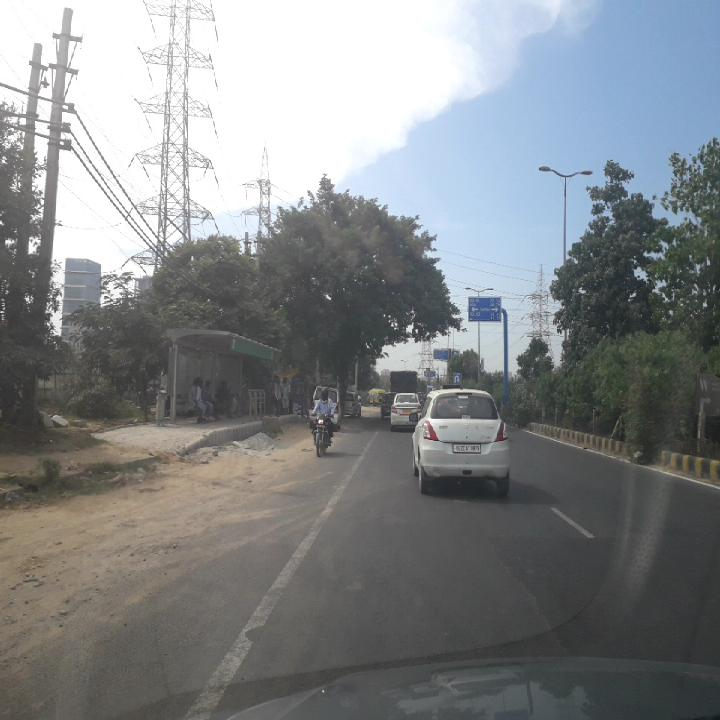


Image: /content/RDD2022/India/yolo_dataset/images/val/India_003416.jpg
Detections: 0


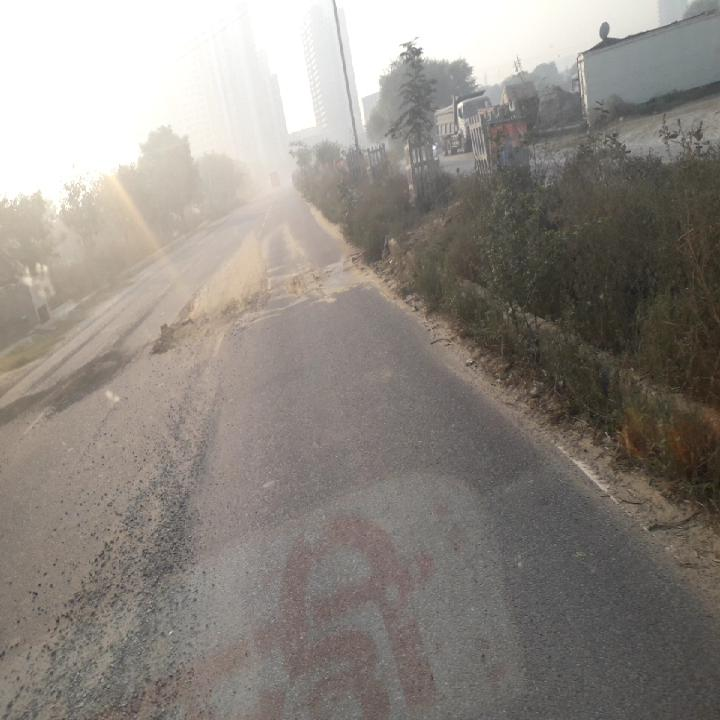


Image: /content/RDD2022/India/yolo_dataset/images/val/India_005286.jpg
Detections: 1


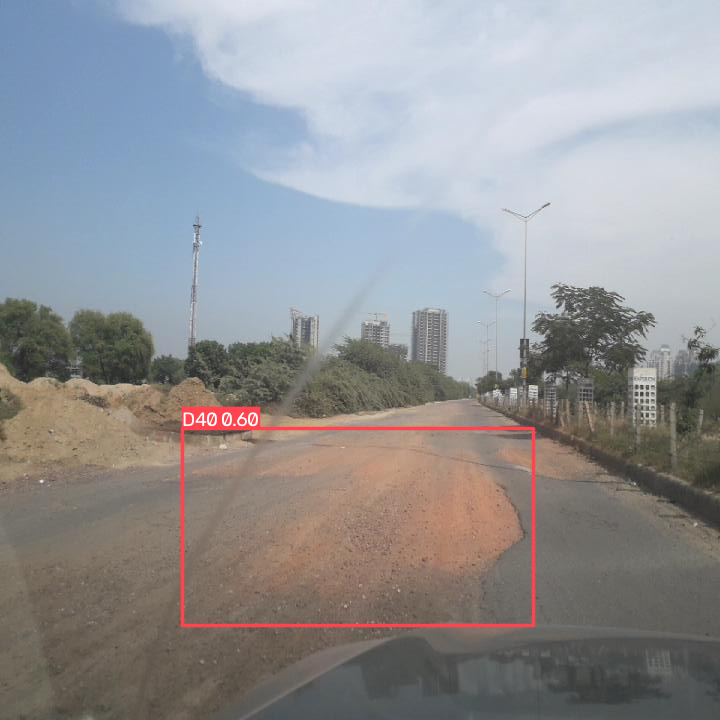


Image: /content/RDD2022/India/yolo_dataset/images/val/India_000412.jpg
Detections: 1


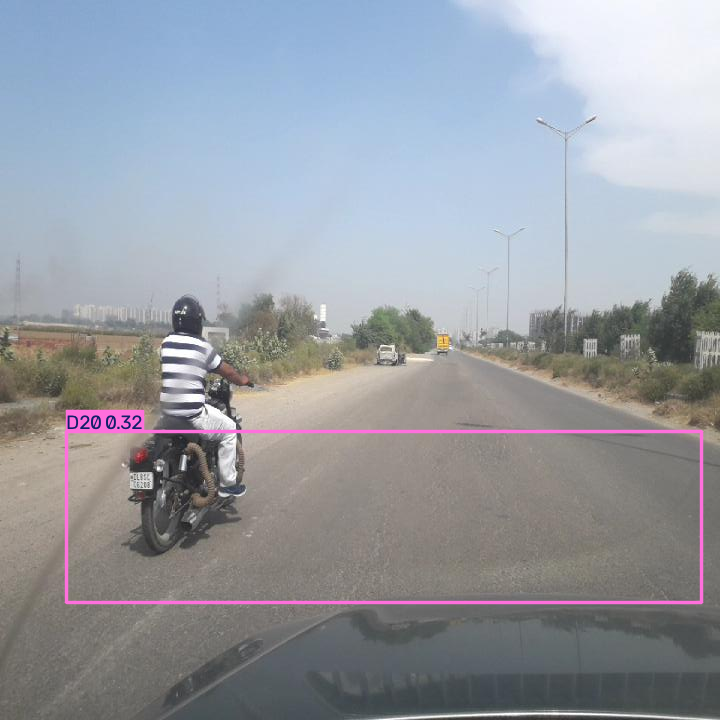


Image: /content/RDD2022/India/yolo_dataset/images/val/India_008625.jpg
Detections: 0


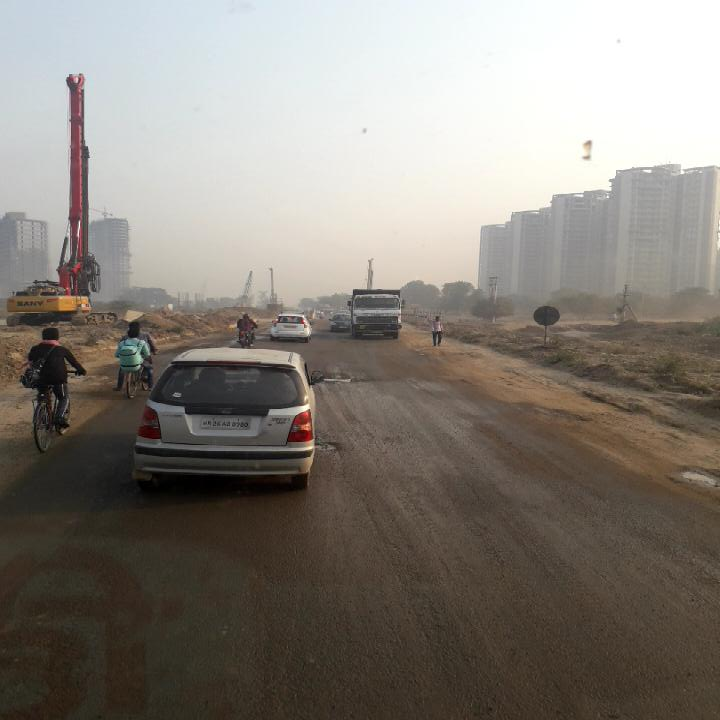

In [47]:
import glob
import random
from IPython.display import display
from PIL import Image

test_images = glob.glob(
    "/content/RDD2022/India/yolo_dataset/images/val/*.jpg"
)

samples = random.sample(test_images, 5)

for img in samples:
    result = model.predict(source=img, conf=0.25, verbose=False)[0]
    print("\nImage:", img)
    print("Detections:", len(result.boxes))
    display(Image.fromarray(result.plot()[..., ::-1]))


In [48]:
import os

folder = "/content/drive/MyDrive/Road_damage_ai"

print("Folder exists:", os.path.exists(folder))
print("Files:", os.listdir(folder))

Folder exists: True
Files: ['India.zip', 'RDD2022_India_yolo26n_3epoch_best.pt']


In [49]:
zip_path = "/content/drive/MyDrive/Road_damage_ai/India.zip"

print("India.zip exists:", os.path.exists(zip_path))
print("Size (MB):", round(os.path.getsize(zip_path) / (1024*1024), 2))

India.zip exists: True
Size (MB): 502.31


In [1]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [2]:
import os

project = "/content/drive/MyDrive/Road_damage_ai"

print("Folder exists:", os.path.exists(project))
print("Contents:", os.listdir(project))

Folder exists: True
Contents: ['India.zip', 'RDD2022_India_yolo26n_3epoch_best.pt']


In [3]:
zip_path = "/content/drive/MyDrive/Road_damage_ai/India.zip"

print("India.zip exists:", os.path.exists(zip_path))
print("Size (MB):", round(os.path.getsize(zip_path)/(1024*1024), 2))


India.zip exists: True
Size (MB): 502.31


In [4]:
import zipfile

zip_path = "/content/drive/MyDrive/Road_damage_ai/India.zip"

with zipfile.ZipFile(zip_path, "r") as z:
    files = z.namelist()

print("Total files:", len(files))
print("\nFirst 20 files:")
for f in files[:20]:
    print(f)

Total files: 17377

First 20 files:
India/test/
India/test/images/
India/test/images/India_000004.jpg
India/test/images/India_000006.jpg
India/test/images/India_000008.jpg
India/test/images/India_000009.jpg
India/test/images/India_000013.jpg
India/test/images/India_000015.jpg
India/test/images/India_000020.jpg
India/test/images/India_000021.jpg
India/test/images/India_000025.jpg
India/test/images/India_000029.jpg
India/test/images/India_000030.jpg
India/test/images/India_000031.jpg
India/test/images/India_000033.jpg
India/test/images/India_000034.jpg
India/test/images/India_000045.jpg
India/test/images/India_000048.jpg
India/test/images/India_000050.jpg
India/test/images/India_000051.jpg


In [5]:
import os

print("Drive folder:")
print(os.listdir("/content/drive/MyDrive/Road_damage_ai"))

Drive folder:
['India.zip', 'RDD2022_India_yolo26n_3epoch_best.pt']


In [6]:
import os

print("Drive folder:")
print(os.listdir("/content/drive/MyDrive/Road_damage_ai"))

Drive folder:
['India.zip', 'RDD2022_India_yolo26n_3epoch_best.pt']


In [7]:
import zipfile
import os

zip_path = "/content/drive/MyDrive/Road_damage_ai/India.zip"
extract_path = "/content"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Extraction complete.")

Extraction complete.


In [8]:
!find /content -maxdepth 3 -type d | head -100

/content
/content/.config
/content/.config/logs
/content/.config/logs/2026.09.04
/content/.config/configurations
/content/drive
/content/drive/.shortcut-targets-by-id
/content/drive/MyDrive
/content/drive/MyDrive/Colab Notebooks
/content/drive/MyDrive/Road_damage_ai
/content/drive/Othercomputers
/content/drive/Othercomputers/My MacBook Air (1)
/content/drive/Othercomputers/My MacBook Air
/content/drive/.Trash-0
/content/drive/.Trash-0/files
/content/drive/.Trash-0/info
/content/drive/.Encrypted
/content/drive/.Encrypted/.shortcut-targets-by-id
/content/drive/.Encrypted/MyDrive
/content/India
/content/India/test
/content/India/test/images
/content/India/train
/content/India/train/annotations
/content/India/train/images
/content/sample_data


In [9]:
import zipfile
import os

zip_path = "/content/drive/MyDrive/Road_damage_ai/India.zip"

with zipfile.ZipFile(zip_path, 'r') as z:
    files = z.namelist()

print("Total files:", len(files))
print("\nFirst 30 files:")
for f in files[:30]:
    print(f)

Total files: 17377

First 30 files:
India/test/
India/test/images/
India/test/images/India_000004.jpg
India/test/images/India_000006.jpg
India/test/images/India_000008.jpg
India/test/images/India_000009.jpg
India/test/images/India_000013.jpg
India/test/images/India_000015.jpg
India/test/images/India_000020.jpg
India/test/images/India_000021.jpg
India/test/images/India_000025.jpg
India/test/images/India_000029.jpg
India/test/images/India_000030.jpg
India/test/images/India_000031.jpg
India/test/images/India_000033.jpg
India/test/images/India_000034.jpg
India/test/images/India_000045.jpg
India/test/images/India_000048.jpg
India/test/images/India_000050.jpg
India/test/images/India_000051.jpg
India/test/images/India_000056.jpg
India/test/images/India_000058.jpg
India/test/images/India_000060.jpg
India/test/images/India_000062.jpg
India/test/images/India_000063.jpg
India/test/images/India_000065.jpg
India/test/images/India_000068.jpg
India/test/images/India_000070.jpg
India/test/images/India

In [10]:
import os

base = "/content/India"

for path in [
    f"{base}/train/images",
    f"{base}/train/annotations",
    f"{base}/test/images",
]:
    print("\n", path)
    print("Exists:", os.path.exists(path))
    if os.path.exists(path):
        print("Files:", len(os.listdir(path)))


 /content/India/train/images
Exists: True
Files: 7706

 /content/India/train/annotations
Exists: True
Files: 1

 /content/India/test/images
Exists: True
Files: 1959


In [11]:
import os

base = "/content/India"

print("=== TRAIN ===")
for folder in ["images", "annotations", "labels"]:
    path = f"{base}/train/{folder}"
    print(f"\n{folder}:")
    print("  Exists:", os.path.exists(path))
    if os.path.exists(path):
        files = os.listdir(path)
        print("  Count:", len(files))
        print("  First 10:", files[:10])

print("\n=== TEST ===")
path = f"{base}/test/images"
print("test/images exists:", os.path.exists(path))
print("test images:", len(os.listdir(path)))

=== TRAIN ===

images:
  Exists: True
  Count: 7706
  First 10: ['India_002950.jpg', 'India_003836.jpg', 'India_005421.jpg', 'India_007422.jpg', 'India_007985.jpg', 'India_009243.jpg', 'India_001270.jpg', 'India_004738.jpg', 'India_009315.jpg', 'India_006797.jpg']

annotations:
  Exists: True
  Count: 1
  First 10: ['xmls']

labels:
  Exists: False

=== TEST ===
test/images exists: True
test images: 1959


In [12]:
import os

xml_dir = "/content/India/train/annotations/xmls"

print("XML folder exists:", os.path.exists(xml_dir))

if os.path.exists(xml_dir):
    xml_files = [f for f in os.listdir(xml_dir) if f.lower().endswith(".xml")]
    print("XML annotation files:", len(xml_files))
    print("First 10:", xml_files[:10])

XML folder exists: True
XML annotation files: 7706
First 10: ['India_009348.xml', 'India_009536.xml', 'India_001665.xml', 'India_000249.xml', 'India_000171.xml', 'India_005364.xml', 'India_000647.xml', 'India_002854.xml', 'India_003263.xml', 'India_004780.xml']


In [13]:
import os
import xml.etree.ElementTree as ET

xml_dir = "/content/India/train/annotations/xmls"

# See what damage classes actually exist in the India annotations
classes = set()

for file in os.listdir(xml_dir):
    if file.endswith(".xml"):
        root = ET.parse(os.path.join(xml_dir, file)).getroot()

        for obj in root.findall("object"):
            name = obj.find("name").text.strip()
            classes.add(name)

print("Number of classes:", len(classes))
print("Classes found:")
for c in sorted(classes):
    print("-", c)

Number of classes: 10
Classes found:
- D00
- D01
- D0w0
- D10
- D11
- D20
- D40
- D43
- D44
- D50


In [14]:
import os
import xml.etree.ElementTree as ET

# Paths
base = "/content/India"
image_dir = f"{base}/train/images"
xml_dir = f"{base}/train/annotations/xmls"
label_dir = f"{base}/train/labels"

os.makedirs(label_dir, exist_ok=True)

# Exact class mapping found in your dataset
classes = [
    "D00",
    "D01",
    "D0w0",
    "D10",
    "D11",
    "D20",
    "D40",
    "D43",
    "D44",
    "D50"
]

class_to_id = {name: i for i, name in enumerate(classes)}

converted = 0
skipped = 0

for xml_file in os.listdir(xml_dir):

    if not xml_file.endswith(".xml"):
        continue

    xml_path = os.path.join(xml_dir, xml_file)
    root = ET.parse(xml_path).getroot()

    # Get image dimensions
    size = root.find("size")

    if size is None:
        skipped += 1
        continue

    width = float(size.find("width").text)
    height = float(size.find("height").text)

    yolo_lines = []

    for obj in root.findall("object"):

        name = obj.find("name").text.strip()

        if name not in class_to_id:
            print("Unknown class:", name)
            continue

        bbox = obj.find("bndbox")

        xmin = float(bbox.find("xmin").text)
        ymin = float(bbox.find("ymin").text)
        xmax = float(bbox.find("xmax").text)
        ymax = float(bbox.find("ymax").text)

        # Convert Pascal VOC -> YOLO
        x_center = ((xmin + xmax) / 2) / width
        y_center = ((ymin + ymax) / 2) / height

        box_width = (xmax - xmin) / width
        box_height = (ymax - ymin) / height

        class_id = class_to_id[name]

        yolo_lines.append(
            f"{class_id} {x_center:.6f} {y_center:.6f} "
            f"{box_width:.6f} {box_height:.6f}"
        )

    # Same filename as image, but .txt
    txt_name = os.path.splitext(xml_file)[0] + ".txt"
    txt_path = os.path.join(label_dir, txt_name)

    with open(txt_path, "w") as f:
        f.write("\n".join(yolo_lines))

    converted += 1

print("===================================")
print("XML files converted:", converted)
print("Skipped:", skipped)
print("YOLO labels created:", len(os.listdir(label_dir)))
print("===================================")

XML files converted: 7706
Skipped: 0
YOLO labels created: 7706


In [15]:
import os
import shutil
import random

base = "/content/India"

image_src = f"{base}/train/images"
label_src = f"{base}/train/labels"

dataset = f"{base}/yolo_dataset"

train_img = f"{dataset}/images/train"
val_img = f"{dataset}/images/val"
train_lbl = f"{dataset}/labels/train"
val_lbl = f"{dataset}/labels/val"

for folder in [train_img, val_img, train_lbl, val_lbl]:
    os.makedirs(folder, exist_ok=True)

# Find images that have matching YOLO labels
images = [
    f for f in os.listdir(image_src)
    if f.lower().endswith((".jpg", ".jpeg", ".png"))
    and os.path.exists(
        os.path.join(label_src, os.path.splitext(f)[0] + ".txt")
    )
]

print("Valid image-label pairs:", len(images))

# Reproducible 80/20 split
random.seed(42)
random.shuffle(images)

split = int(len(images) * 0.8)

train_images = images[:split]
val_images = images[split:]

print("Train pairs:", len(train_images))
print("Validation pairs:", len(val_images))

# Copy files
for img in train_images:
    shutil.copy2(
        os.path.join(image_src, img),
        os.path.join(train_img, img)
    )
    label = os.path.splitext(img)[0] + ".txt"
    shutil.copy2(
        os.path.join(label_src, label),
        os.path.join(train_lbl, label)
    )

for img in val_images:
    shutil.copy2(
        os.path.join(image_src, img),
        os.path.join(val_img, img)
    )
    label = os.path.splitext(img)[0] + ".txt"
    shutil.copy2(
        os.path.join(label_src, label),
        os.path.join(val_lbl, label)
    )

print("\nDataset split complete!")
print("Train images:", len(os.listdir(train_img)))
print("Train labels:", len(os.listdir(train_lbl)))
print("Val images:", len(os.listdir(val_img)))
print("Val labels:", len(os.listdir(val_lbl)))

Valid image-label pairs: 7706
Train pairs: 6164
Validation pairs: 1542

Dataset split complete!
Train images: 6164
Train labels: 6164
Val images: 1542
Val labels: 1542


In [16]:
Valid image-label pairs: 7706
Train pairs: 6164
Validation pairs: 1542

Dataset split complete!
Train images: 6164
Train labels: 6164
Val images: 1542
Val labels: 1542

SyntaxError: invalid syntax (794267679.py, line 1)

In [17]:
import os

print("=== INDIA DATASET CHECK ===")

# Original dataset
train_images = "/content/India/train/images"
train_labels = "/content/India/train/labels"
test_images = "/content/India/test/images"

print("\nOriginal training images:")
print("Exists:", os.path.exists(train_images))
print("Count:", len(os.listdir(train_images)) if os.path.exists(train_images) else 0)

print("\nYOLO labels:")
print("Exists:", os.path.exists(train_labels))
print("Count:", len(os.listdir(train_labels)) if os.path.exists(train_labels) else 0)

print("\nTest images:")
print("Exists:", os.path.exists(test_images))
print("Count:", len(os.listdir(test_images)) if os.path.exists(test_images) else 0)

# Check image/label matching
if os.path.exists(train_images) and os.path.exists(train_labels):
    image_files = {
        os.path.splitext(f)[0]
        for f in os.listdir(train_images)
        if f.lower().endswith((".jpg", ".jpeg", ".png"))
    }

    label_files = {
        os.path.splitext(f)[0]
        for f in os.listdir(train_labels)
        if f.lower().endswith(".txt")
    }

    matched = image_files & label_files
    missing_labels = image_files - label_files
    missing_images = label_files - image_files

    print("\n=== MATCHING CHECK ===")
    print("Images:", len(image_files))
    print("Labels:", len(label_files))
    print("Matched pairs:", len(matched))
    print("Images without labels:", len(missing_labels))
    print("Labels without images:", len(missing_images))

    if len(missing_labels) == 0 and len(missing_images) == 0:
        print("\n✅ DATASET CHECK PASSED")
    else:
        print("\n⚠️ Some images/labels do not match.")

=== INDIA DATASET CHECK ===

Original training images:
Exists: True
Count: 7706

YOLO labels:
Exists: True
Count: 7706

Test images:
Exists: True
Count: 1959

=== MATCHING CHECK ===
Images: 7706
Labels: 7706
Matched pairs: 7706
Images without labels: 0
Labels without images: 0

✅ DATASET CHECK PASSED


In [19]:
import os
import shutil
import random

# Paths
BASE = "/content/India"
IMAGES = f"{BASE}/train/images"
LABELS = f"{BASE}/train/labels"

YOLO_DATASET = f"{BASE}/yolo_dataset"

TRAIN_IMG = f"{YOLO_DATASET}/images/train"
VAL_IMG = f"{YOLO_DATASET}/images/val"
TRAIN_LBL = f"{YOLO_DATASET}/labels/train"
VAL_LBL = f"{YOLO_DATASET}/labels/val"

# Create folders
for folder in [TRAIN_IMG, VAL_IMG, TRAIN_LBL, VAL_LBL]:
    os.makedirs(folder, exist_ok=True)

# Get matching image files
images = [
    f for f in os.listdir(IMAGES)
    if f.lower().endswith((".jpg", ".jpeg", ".png"))
]

# Shuffle reproducibly
random.seed(42)
random.shuffle(images)

# 80/20 split
split = int(len(images) * 0.8)

train_files = images[:split]
val_files = images[split:]

print("Total images:", len(images))
print("Training images:", len(train_files))
print("Validation images:", len(val_files))

# Copy images + labels
for filename in train_files:
    src_img = os.path.join(IMAGES, filename)
    src_lbl = os.path.join(LABELS, os.path.splitext(filename)[0] + ".txt")

    shutil.copy2(src_img, TRAIN_IMG)
    shutil.copy2(src_lbl, TRAIN_LBL)

for filename in val_files:
    src_img = os.path.join(IMAGES, filename)
    src_lbl = os.path.join(LABELS, os.path.splitext(filename)[0] + ".txt")

    shutil.copy2(src_img, VAL_IMG)
    shutil.copy2(src_lbl, VAL_LBL)

print("\n✅ TRAIN/VALIDATION SPLIT COMPLETE")

Total images: 7706
Training images: 6164
Validation images: 1542

✅ TRAIN/VALIDATION SPLIT COMPLETE


In [20]:
import os

BASE = "/content/India/yolo_dataset"

folders = {
    "Train images": f"{BASE}/images/train",
    "Train labels": f"{BASE}/labels/train",
    "Val images": f"{BASE}/images/val",
    "Val labels": f"{BASE}/labels/val",
}

print("=== YOLO DATASET CHECK ===\n")

for name, path in folders.items():
    exists = os.path.exists(path)
    count = len(os.listdir(path)) if exists else 0
    print(f"{name}:")
    print(f"  Exists: {exists}")
    print(f"  Count: {count}\n")

# Check image-label matching
train_images = {
    os.path.splitext(f)[0]
    for f in os.listdir(f"{BASE}/images/train")
    if f.lower().endswith((".jpg", ".jpeg", ".png"))
}

train_labels = {
    os.path.splitext(f)[0]
    for f in os.listdir(f"{BASE}/labels/train")
    if f.endswith(".txt")
}

val_images = {
    os.path.splitext(f)[0]
    for f in os.listdir(f"{BASE}/images/val")
    if f.lower().endswith((".jpg", ".jpeg", ".png"))
}

val_labels = {
    os.path.splitext(f)[0]
    for f in os.listdir(f"{BASE}/labels/val")
    if f.endswith(".txt")
}

print("=== MATCHING ===")
print("Train matched:", len(train_images & train_labels))
print("Train missing labels:", len(train_images - train_labels))
print("Train missing images:", len(train_labels - train_images))

print("Val matched:", len(val_images & val_labels))
print("Val missing labels:", len(val_images - val_labels))
print("Val missing images:", len(val_labels - val_images))

=== YOLO DATASET CHECK ===

Train images:
  Exists: True
  Count: 6164

Train labels:
  Exists: True
  Count: 6164

Val images:
  Exists: True
  Count: 1542

Val labels:
  Exists: True
  Count: 1542

=== MATCHING ===
Train matched: 6164
Train missing labels: 0
Train missing images: 0
Val matched: 1542
Val missing labels: 0
Val missing images: 0


In [21]:
import os

yaml_path = "/content/India/data.yaml"

yaml_content = """path: /content/India/yolo_dataset
train: images/train
val: images/val

names:
  0: D00
  1: D01
  2: D0w0
  3: D10
  4: D11
  5: D20
  6: D40
  7: D43
  8: D44
  9: D50
"""

with open(yaml_path, "w") as f:
    f.write(yaml_content)

print("✅ data.yaml created")
print("\nContents:\n")
print(open(yaml_path).read())

✅ data.yaml created

Contents:

path: /content/India/yolo_dataset
train: images/train
val: images/val

names:
  0: D00
  1: D01
  2: D0w0
  3: D10
  4: D11
  5: D20
  6: D40
  7: D43
  8: D44
  9: D50



In [22]:
!pip install -q ultralytics


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.7/46.7 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 39.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.0/91.0 kB 10.7 MB/s eta 0:00:00


In [23]:
import torch
import ultralytics

print("Ultralytics version:", ultralytics.__version__)
print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("⚠️ GPU NOT AVAILABLE")

Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/usage/settings.
Ultralytics version: 8.4.163
PyTorch version: 2.11.0+cu128
CUDA available: True
GPU: Tesla T4


In [24]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [25]:
import os

MODEL_PATH = "/content/drive/MyDrive/Road_damage_ai/RDD2022_best.pt"
DATA_PATH = "/content/India/data.yaml"
PROJECT_PATH = "/content/drive/MyDrive/Road_damage_ai/India_training"

print("Model exists:", os.path.exists(MODEL_PATH))
print("Dataset YAML exists:", os.path.exists(DATA_PATH))
print("Training output folder:", PROJECT_PATH)

os.makedirs(PROJECT_PATH, exist_ok=True)

if os.path.exists(MODEL_PATH):
    print("Model size (MB):", round(os.path.getsize(MODEL_PATH) / (1024**2), 2))

Model exists: False
Dataset YAML exists: True
Training output folder: /content/drive/MyDrive/Road_damage_ai/India_training


In [26]:
import os

MODEL_PATH = "/content/drive/MyDrive/Road_damage_ai/RDD2022_India_yolo26n_3epoch_best.pt"

print("Model exists:", os.path.exists(MODEL_PATH))

if os.path.exists(MODEL_PATH):
    print("Model size (MB):", round(os.path.getsize(MODEL_PATH) / (1024**2), 2))

Model exists: True
Model size (MB): 5.14


In [27]:
from ultralytics import YOLO

MODEL_PATH = "/content/drive/MyDrive/Road_damage_ai/RDD2022_India_yolo26n_3epoch_best.pt"

model = YOLO(MODEL_PATH)

print("✅ Model loaded successfully")
print("Model:", MODEL_PATH)

✅ Model loaded successfully
Model: /content/drive/MyDrive/Road_damage_ai/RDD2022_India_yolo26n_3epoch_best.pt


In [33]:
import os

base = "/content/drive/MyDrive/Road_damage_ai/India_training"

for root, dirs, files in os.walk(base):
    for f in files:
        if f.endswith((".pt", ".png", ".csv")):
            print(os.path.join(root, f))

In [34]:
import os

base = "/content/drive/MyDrive/Road_damage_ai/India_training"

print("Training folder exists:", os.path.exists(base))

print("\nFiles inside training output:")
for root, dirs, files in os.walk(base):
    for f in files:
        print(os.path.join(root, f))

Training folder exists: True

Files inside training output:


In [35]:
import os

base = "/content/drive/MyDrive/Road_damage_ai/India_training"

print("Training folder exists:", os.path.exists(base))

if os.path.exists(base):
    for root, dirs, files in os.walk(base):
        level = root.replace(base, "").count(os.sep)
        indent = "  " * level
        print(f"{indent}{os.path.basename(root)}/")
        for f in files:
            print(f"{indent}  {f}")

Training folder exists: True
India_training/


In [36]:
import os

base = "/content/drive/MyDrive/Road_damage_ai/India_training"

for root, dirs, files in os.walk(base):
    print("\nFOLDER:", root)
    print("FILES:", files)


FOLDER: /content/drive/MyDrive/Road_damage_ai/India_training
FILES: []


In [37]:
import os

base = "/content/drive/MyDrive/Road_damage_ai"

for root, dirs, files in os.walk(base):
    for f in files:
        if f.endswith(".pt"):
            path = os.path.join(root, f)
            print(path)

/content/drive/MyDrive/Road_damage_ai/RDD2022_India_yolo26n_3epoch_best.pt


In [38]:
import os

model_path = "/content/drive/MyDrive/Road_damage_ai/RDD2022_India_yolo26n_3epoch_best.pt"

print("Model exists:", os.path.exists(model_path))

if os.path.exists(model_path):
    print("Model size:", round(os.path.getsize(model_path) / (1024*1024), 2), "MB")

Model exists: True
Model size: 5.14 MB


In [39]:
import os

pt_files = [f for f in os.listdir("/content") if f.endswith(".pt")]

print("PT files found:")
for f in pt_files:
    path = os.path.join("/content", f)
    print(f"- {f}  ({os.path.getsize(path)/(1024*1024):.2f} MB)")

PT files found:
- RDD2022_India_yolo26n_3epoch_best (1).pt  (5.14 MB)


In [41]:
from ultralytics import YOLO
import os

model_path = "/content/RDD2022_India_yolo26n_3epoch_best (1).pt"

print("File exists:", os.path.exists(model_path))
print("File size:", round(os.path.getsize(model_path)/(1024*1024), 2), "MB")

model = YOLO(model_path)

print("\n✅ MODEL LOADED")
print("Classes:")
print(model.names)

# Check checkpoint training information if available
if hasattr(model, "ckpt") and model.ckpt:
    print("\nCheckpoint information:")
    args = model.ckpt.get("train_args", {})
    print("Epochs recorded:", args.get("epochs", "Not available"))
    print("Image size:", args.get("imgsz", "Not available"))
    print("Model:", args.get("model", "Not available"))

File exists: True
File size: 5.14 MB

✅ MODEL LOADED
Classes:
{0: 'D00', 1: 'D01', 2: 'D0w0', 3: 'D10', 4: 'D11', 5: 'D20', 6: 'D40', 7: 'D43', 8: 'D44', 9: 'D50'}

Checkpoint information:
Epochs recorded: 3
Image size: 640
Model: yolo26n.pt


In [40]:
from ultralytics import YOLO

model_path = "/content/PUT_THE_EXACT_FILENAME_HERE.pt"

model = YOLO(model_path)

print("✅ Teammate's model loaded successfully")
print(model.names)

FileNotFoundError: [Errno 2] No such file or directory: '/content/PUT_THE_EXACT_FILENAME_HERE.pt'

In [42]:
import os

path = "/content/best(1).pt"

print("Exists:", os.path.exists(path))

if os.path.exists(path):
    print("Size:", round(os.path.getsize(path)/(1024*1024), 2), "MB")

Exists: False


In [43]:
import os

print("PT files currently in /content:")

for f in os.listdir("/content"):
    if f.lower().endswith(".pt"):
        print(repr(f))

PT files currently in /content:
'best.pt'


In [44]:
from ultralytics import YOLO

path = "/content/best.pt"

model = YOLO(path)

print("✅ Model loaded")
print("Classes:", model.names)

if hasattr(model, "ckpt") and model.ckpt:
    args = model.ckpt.get("train_args", {})
    print("Epochs recorded:", args.get("epochs", "Not available"))
    print("Image size:", args.get("imgsz", "Not available"))
    print("Model:", args.get("model", "Not available"))

✅ Model loaded
Classes: {0: 'D00', 1: 'D01', 2: 'D0w0', 3: 'D10', 4: 'D11', 5: 'D20', 6: 'D40', 7: 'D43', 8: 'D44', 9: 'D50'}
Epochs recorded: 30
Image size: 640
Model: yolo26n.pt


In [45]:
import shutil
import os

src = "/content/best.pt"
dst = "/content/drive/MyDrive/Road_damage_ai/RDD2022_India_yolo26n_30epoch_best.pt"

shutil.copy2(src, dst)

print("Saved:", os.path.exists(dst))
print("Path:", dst)

if os.path.exists(dst):
    print("Size (MB):", round(os.path.getsize(dst)/(1024*1024), 2))

Saved: True
Path: /content/drive/MyDrive/Road_damage_ai/RDD2022_India_yolo26n_30epoch_best.pt
Size (MB): 5.14


In [46]:
from ultralytics import YOLO
import os

path = "/content/drive/MyDrive/Road_damage_ai/RDD2022_India_yolo26n_30epoch_best.pt"

print("Exists:", os.path.exists(path))

model = YOLO(path)

print("✅ Drive copy loads successfully")
print("Classes:", model.names)

if hasattr(model, "ckpt") and model.ckpt:
    args = model.ckpt.get("train_args", {})
    print("Epochs:", args.get("epochs", "Not available"))
    print("Image size:", args.get("imgsz", "Not available"))

Exists: True
✅ Drive copy loads successfully
Classes: {0: 'D00', 1: 'D01', 2: 'D0w0', 3: 'D10', 4: 'D11', 5: 'D20', 6: 'D40', 7: 'D43', 8: 'D44', 9: 'D50'}
Epochs: 30
Image size: 640


In [47]:
!git clone https://github.com/CodeandAshwani/roadDamage-detection-Ai.git

Cloning into 'roadDamage-detection-Ai'...
remote: Enumerating objects: 66, done.
remote: Counting objects: 100% (66/66), done.
remote: Compressing objects: 100% (61/61), done.
remote: Total 66 (delta 9), reused 40 (delta 2), pack-reused 0 (from 0)
Receiving objects: 100% (66/66), 43.51 KiB | 2.90 MiB/s, done.
Resolving deltas: 100% (9/9), done.


In [48]:
%cd roadDamage-detection-Ai
!git checkout main
!git pull origin main

/content/roadDamage-detection-Ai
Already on 'main'
Your branch is up to date with 'origin/main'.
From https://github.com/CodeandAshwani/roadDamage-detection-Ai
 * branch            main       -> FETCH_HEAD
Already up to date.


In [51]:
!cp "/content/drive/MyDrive/Road_damage_ai/RDD2022_India_yolo26n_30epoch_best.pt" .

In [53]:
!ls -lh *.pt

-rw------- 1 root root 5.2M Sep 26 21:07 RDD2022_India_yolo26n_30epoch_best.pt


In [54]:
!git add RDD2022_India_yolo26n_30epoch_best.pt
!git commit -m "Add 30-epoch India road damage model"
!git push origin main

Author identity unknown

*** Please tell me who you are.

Run

  git config --global user.email "you@example.com"
  git config --global user.name "Your Name"

to set your account's default identity.
Omit --global to set the identity only in this repository.

fatal: unable to auto-detect email address (got 'root@afeb583ec210.(none)')
fatal: could not read Username for 'https://github.com': No such device or address


In [56]:
from ultralytics import YOLO

model = YOLO(
    "/content/drive/MyDrive/Road_damage_ai/RDD2022_India_yolo26n_30epoch_best.pt"
)

print("✅ Model loaded")

✅ Model loaded


In [57]:
test_image = "/content/India/test/images/India_000004.jpg"

results = model.predict(
    source=test_image,
    conf=0.25,
    save=True
)

print("✅ Prediction complete")


image 1/1 /content/India/test/images/India_000004.jpg: 640x640 1 D44, 9.7ms
Speed: 196.0ms preprocess, 9.7ms inference, 37.0ms postprocess per image at shape (1, 3, 640, 640)
Results saved to /content/roadDamage-detection-Ai/runs/detect/predict
✅ Prediction complete


In [58]:
from IPython.display import Image, display
import glob

result_file = glob.glob("/content/runs/detect/predict/*.jpg")[0]
display(Image(filename=result_file))

IndexError: list index out of range

Result files: ['/content/roadDamage-detection-Ai/runs/detect/predict/India_000004.jpg']


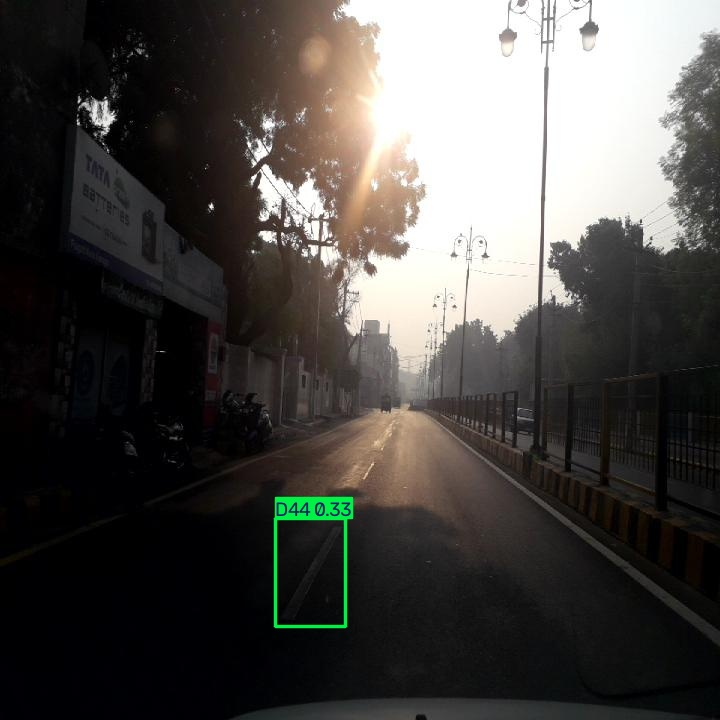

In [59]:
from IPython.display import Image, display
import glob
import os

result_files = glob.glob(
    "/content/roadDamage-detection-Ai/runs/detect/predict/*"
)

print("Result files:", result_files)

display(Image(filename=result_files[0]))

Found: ['/content/roadDamage-detection-Ai/runs/detect/predict/India_000004.jpg']


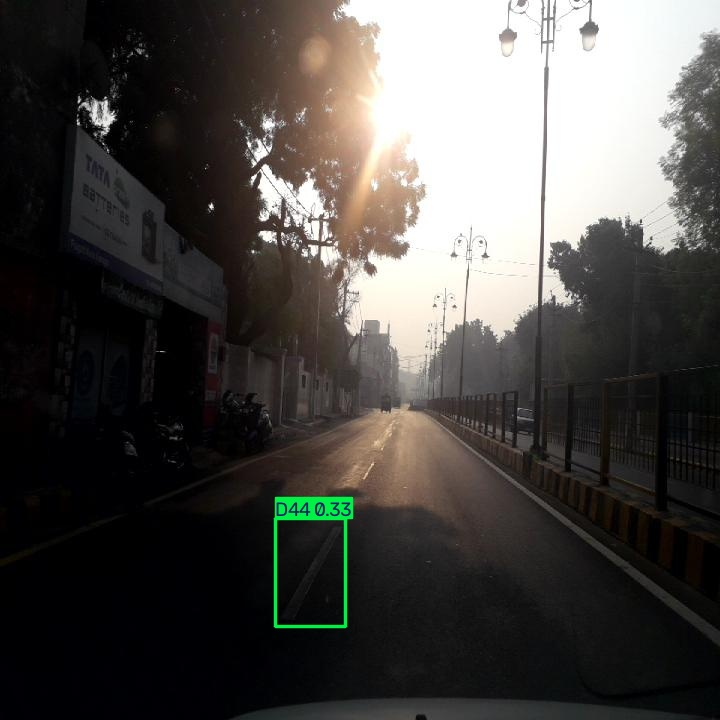

In [60]:
from IPython.display import Image, display
import glob

result_files = glob.glob(
    "/content/roadDamage-detection-Ai/runs/detect/predict/*"
)

print("Found:", result_files)

display(Image(filename=result_files[0]))

In [61]:
from ultralytics import YOLO

model = YOLO(
    "/content/drive/MyDrive/Road_damage_ai/RDD2022_India_yolo26n_30epoch_best.pt"
)

results = model.val(
    data="/content/India/data.yaml",
    split="test",
    imgsz=640
)

Ultralytics 8.4.163 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO26n summary (fused): 120 layers, 2,376,786 parameters, 0 gradients, 5.3 GFLOPs


FileNotFoundError: /content/India/data.yaml 'test:' images not found ❌

In [62]:
from ultralytics import YOLO

model = YOLO("/content/best.pt")

results = model.val(
    data="/content/India/data.yaml",
    split="val",
    imgsz=640
)

print("Validation complete!")
print("mAP50:", results.box.map50)
print("mAP50-95:", results.box.map)

Ultralytics 8.4.163 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO26n summary (fused): 120 layers, 2,376,786 parameters, 0 gradients, 5.3 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1461.4±431.7 MB/s, size: 74.5 KB)
val: Scanning /content/India/yolo_dataset/labels/val... 1542 images, 814 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1542/1542 929.9it/s 1.7s
val: New cache created: /content/India/yolo_dataset/labels/val.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 97/97 4.9it/s 20.0s
                   all       1542       1622      0.378      0.449      0.374      0.165
                   D00        232        326      0.423      0.319      0.334      0.156
                   D01         17         27      0.429      0.557      0.467      0.194
                   D10         10         11      0.118      0.182      0.189      0.116
                   D11          8         10      0.219 

In [63]:
from ultralytics import YOLO

model = YOLO("/content/best.pt")

results = model.predict(
    source="/content/India/test/images",
    imgsz=640,
    conf=0.25,
    save=True
)

print("✅ Test predictions complete!")


WARNING ⚠️ 
Inference results will accumulate in RAM unless `stream=True` is passed, which can cause out-of-memory errors for large
sources or long-running streams and videos. See https://docs.ultralytics.com/modes/predict for help.

Example:
    results = model(source=..., stream=True)  # generator of Results objects
    for r in results:
        boxes = r.boxes  # Boxes object for bbox outputs
        masks = r.masks  # Masks object for segment masks outputs
        probs = r.probs  # Class probabilities for classification outputs

image 1/1959 /content/India/test/images/India_000004.jpg: 640x640 1 D44, 8.9ms
image 2/1959 /content/India/test/images/India_000006.jpg: 640x640 (no detections), 12.9ms
image 3/1959 /content/India/test/images/India_000008.jpg: 640x640 1 D20, 11.2ms
image 4/1959 /content/India/test/images/India_000009.jpg: 640x640 1 D20, 9.6ms
image 5/1959 /content/India/test/images/India_000013.jpg: 640x640 (no detections), 16.0ms
image 6/1959 /content/India/test/images/I

KeyboardInterrupt: 

In [64]:
from IPython.display import Image, display
import glob

files = glob.glob("/content/runs/detect/predict/*.jpg")

print("Predicted images:", len(files))

if files:
    display(Image(filename=files[0]))

Predicted images: 0


from IPython.display import Image, display
import glob

files = glob.glob("/content/runs/detect/predict/*.jpg")

print("Total predictions:", len(files))

for f in files[:5]:
    display(Image(filename=f))

In [66]:
from IPython.display import Image, display
import glob

files = glob.glob("/content/runs/detect/predict/*.jpg")

print("Total predictions:", len(files))

for f in files[:5]:
    display(Image(filename=f))

Total predictions: 0


In [67]:
results = model.val(
    data="/content/India/data.yaml",
    split="val",
    imgsz=640
)

print("mAP50:", results.box.map50)
print("mAP50-95:", results.box.map)

Ultralytics 8.4.163 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO26n summary (fused): 120 layers, 2,376,786 parameters, 0 gradients, 5.3 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1072.1±263.0 MB/s, size: 55.8 KB)
val: Scanning /content/India/yolo_dataset/labels/val.cache... 1542 images, 814 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1542/1542 208.6Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 97/97 4.9it/s 19.8s
                   all       1542       1622      0.378      0.449      0.374      0.165
                   D00        232        326      0.423      0.319      0.334      0.156
                   D01         17         27      0.429      0.557      0.467      0.194
                   D10         10         11      0.118      0.182      0.189      0.116
                   D11          8         10      0.219        0.4      0.341      0.103
                   D20       

In [68]:
from ultralytics import YOLO

model = YOLO("/content/best.pt")

results = model.val(
    data="/content/India/data.yaml",
    split="val",
    imgsz=640
)

print("\n===== MODEL PERFORMANCE =====")
print("mAP50:", results.box.map50)
print("mAP50-95:", results.box.map)
print("Precision:", results.box.mp)
print("Recall:", results.box.mr)

Ultralytics 8.4.163 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO26n summary (fused): 120 layers, 2,376,786 parameters, 0 gradients, 5.3 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1361.5±432.6 MB/s, size: 51.1 KB)
val: Scanning /content/India/yolo_dataset/labels/val.cache... 1542 images, 814 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1542/1542 202.1Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 97/97 4.8it/s 20.2s
                   all       1542       1622      0.378      0.449      0.374      0.165
                   D00        232        326      0.423      0.319      0.334      0.156
                   D01         17         27      0.429      0.557      0.467      0.194
                   D10         10         11      0.118      0.182      0.189      0.116
                   D11          8         10      0.219        0.4      0.341      0.103
                   D20       

In [69]:
from ultralytics import YOLO

china_model = YOLO("/content/china_best.pt")

print("China model loaded")
print(china_model.names)

FileNotFoundError: [Errno 2] No such file or directory: '/content/china_best.pt'

In [70]:
import glob

china_files = glob.glob("/content/China*.pt")
print(china_files)

['/content/China_Drone_yolo26n_30epoch_best.pt']


In [71]:
from ultralytics import YOLO

china_path = china_files[0]
china_model = YOLO(china_path)

print("✅ China model loaded")
print("Classes:", china_model.names)


✅ China model loaded
Classes: {0: 'Block crack', 1: 'D00', 2: 'D10', 3: 'D20', 4: 'D40', 5: 'Repair'}


Saving bus.jpg to bus.jpg

image 1/1 /content/roadDamage-detection-Ai/bus.jpg: 640x480 (no detections), 9.6ms
Speed: 2.0ms preprocess, 9.6ms inference, 0.7ms postprocess per image at shape (1, 3, 640, 480)


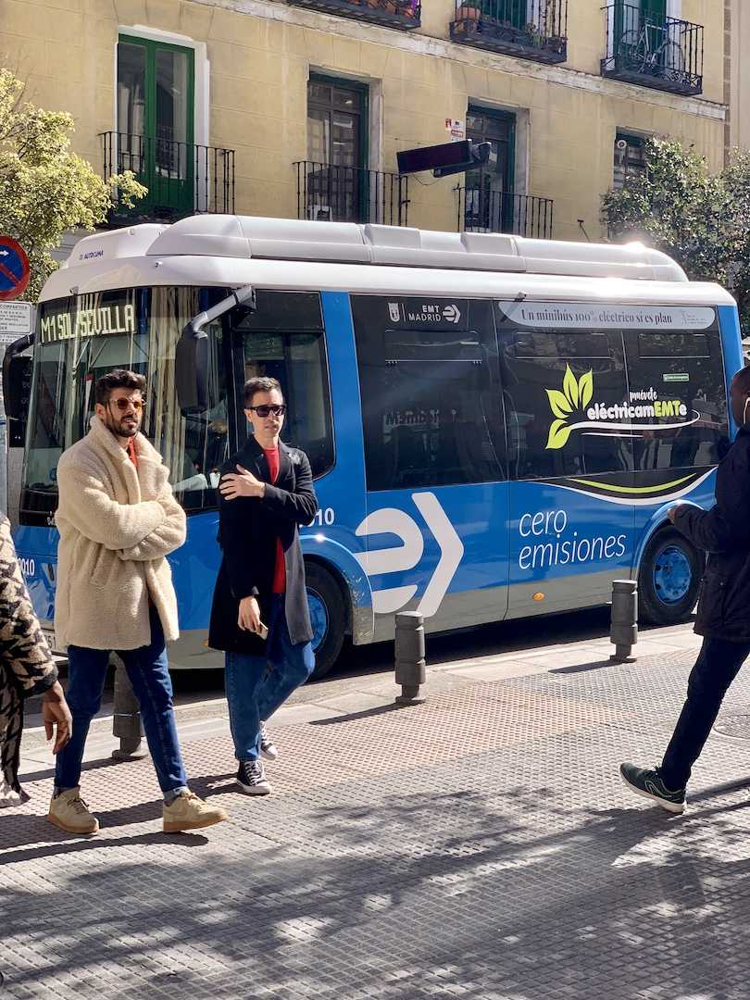

In [72]:
from google.colab import files

uploaded = files.upload()

image_path = list(uploaded.keys())[0]

china_results = china_model.predict(
    source=image_path,
    imgsz=640,
    conf=0.25
)

china_results[0].show()

Saving road.jpg-2.webp to road.jpg-2.webp

image 1/1 /content/roadDamage-detection-Ai/road.jpg-2.webp: 384x640 1 D00, 57.9ms
Speed: 1.8ms preprocess, 57.9ms inference, 1.4ms postprocess per image at shape (1, 3, 384, 640)


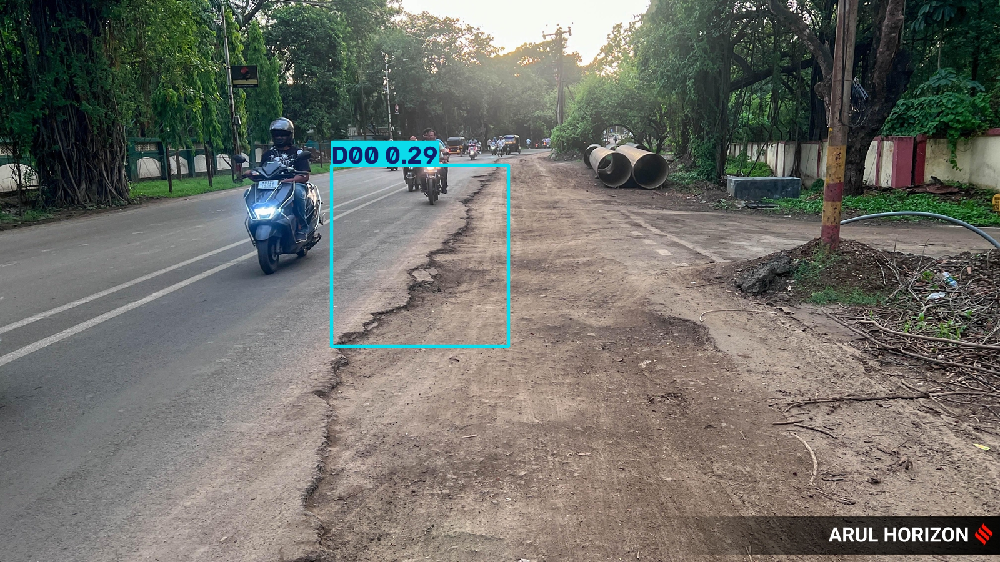

In [73]:
from google.colab import files

uploaded = files.upload()

image_path = list(uploaded.keys())[0]

china_results = china_model.predict(
    source=image_path,
    imgsz=640,
    conf=0.25
)

china_results[0].show()

In [75]:
china_model = YOLO(china_path)

In [1]:
import os

print(os.listdir("/content"))

['.config', 'sample_data']


In [2]:
from ultralytics import YOLO
import glob

india_model = YOLO("/content/best.pt")

china_files = glob.glob("/content/China*.pt")
print(china_files)

china_model = YOLO(china_files[0])

print("India model loaded")
print("China model loaded")
print("China classes:", china_model.names)

ModuleNotFoundError: No module named 'ultralytics'

In [3]:
 !pip install -q ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.7/46.7 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 38.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.1/58.1 kB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.0/91.0 kB 9.0 MB/s eta 0:00:00


In [4]:
from ultralytics import YOLO
print("Ultralytics is ready")

Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/usage/settings.
Ultralytics is ready


In [5]:
import glob

print(glob.glob("/content/*.pt"))

[]


In [6]:
import glob

print(glob.glob("/content/*.pt"))

[]


In [7]:
import glob
print(glob.glob("/content/*.pt"))

[]


In [8]:
from google.colab import drive

drive.mount('/content/drive')


Mounted at /content/drive


In [9]:
!pip install -q ultralytics

In [10]:
from ultralytics import YOLO

india_model = YOLO(
    "/content/drive/MyDrive/Road_damage_ai/RDD2022_India_yolo26n_3epoch_best.pt"
)

print("✅ India model loaded")
print("Classes:", india_model.names)

✅ India model loaded
Classes: {0: 'D00', 1: 'D01', 2: 'D0w0', 3: 'D10', 4: 'D11', 5: 'D20', 6: 'D40', 7: 'D43', 8: 'D44', 9: 'D50'}


In [11]:
import glob

china_files = glob.glob(
    "/content/drive/MyDrive/**/*.pt",
    recursive=True
)

print(china_files)

['/content/drive/MyDrive/RDD2022_best.pt', '/content/drive/MyDrive/Road_damage_ai/RDD2022_India_yolo26n_3epoch_best.pt', '/content/drive/MyDrive/Road_damage_ai/RDD2022_India_yolo26n_30epoch_best.pt']


In [12]:
china_model = YOLO(china_files[0])

print("✅ China model loaded")
print("Classes:", china_model.names)

✅ China model loaded
Classes: {0: 'D00', 1: 'D01', 2: 'D0w0', 3: 'D10', 4: 'D11', 5: 'D20', 6: 'D40', 7: 'D43', 8: 'D44', 9: 'D50'}


In [13]:
import glob

china_files = glob.glob(
    "/content/drive/MyDrive/**/*.pt",
    recursive=True
)

print("Model files found:")
for f in china_files:
    print(f)

Model files found:
/content/drive/MyDrive/RDD2022_best.pt
/content/drive/MyDrive/Road_damage_ai/RDD2022_India_yolo26n_3epoch_best.pt
/content/drive/MyDrive/Road_damage_ai/RDD2022_India_yolo26n_30epoch_best.pt


In [14]:
from ultralytics import YOLO

india_model = YOLO(
    "/content/drive/MyDrive/Road_damage_ai/RDD2022_India_yolo26n_30epoch_best.pt"
)

print("✅ India 30-epoch model loaded")
print("Classes:", india_model.names)

✅ India 30-epoch model loaded
Classes: {0: 'D00', 1: 'D01', 2: 'D0w0', 3: 'D10', 4: 'D11', 5: 'D20', 6: 'D40', 7: 'D43', 8: 'D44', 9: 'D50'}


In [15]:
from ultralytics import YOLO

india_model = YOLO(
    "/content/drive/MyDrive/Road_damage_ai/RDD2022_India_yolo26n_30epoch_best.pt"
)

print("✅ India 30-epoch model loaded")
print("Classes:", india_model.names)

✅ India 30-epoch model loaded
Classes: {0: 'D00', 1: 'D01', 2: 'D0w0', 3: 'D10', 4: 'D11', 5: 'D20', 6: 'D40', 7: 'D43', 8: 'D44', 9: 'D50'}


In [16]:
import glob
from ultralytics import YOLO

# Find China model anywhere inside Google Drive
china_files = glob.glob(
    "/content/drive/MyDrive/**/*.pt",
    recursive=True
)

china_files = [
    f for f in china_files
    if "China" in f or "china" in f
]

print("China model files found:")
for f in china_files:
    print(f)china_path = china_files[0]

china_model = YOLO(china_path)

print("✅ China model loaded")
print("China classes:", china_model.names)

China model files found:


In [17]:
china_path = china_files[0]

china_model = YOLO(china_path)

print("✅ China model loaded")
print("China classes:", china_model.names)

IndexError: list index out of range

In [18]:
import os

print("Checking Road_damage_ai folder...")

folder = "/content/drive/MyDrive/Road_damage_ai"

if os.path.exists(folder):
    print("✅ Folder found")
    print("\nFiles inside:")
    for f in os.listdir(folder):
        print(f)
else:
    print("❌ Folder not found:", folder)

Checking Road_damage_ai folder...
✅ Folder found

Files inside:
India.zip
RDD2022_India_yolo26n_3epoch_best.pt
India_training
RDD2022_India_yolo26n_30epoch_best.pt


In [19]:
import os

folder = "/content/drive/MyDrive/Road_damage_ai"

print("Files now in Road_damage_ai:")
for f in os.listdir(folder):
    print(f)

Files now in Road_damage_ai:
India.zip
RDD2022_India_yolo26n_3epoch_best.pt
India_training
RDD2022_India_yolo26n_30epoch_best.pt
China_Drone_yolo26n_30epoch_best.pt


In [20]:
from ultralytics import YOLO
import os

china_path = "/content/drive/MyDrive/Road_damage_ai/China_Drone_yolo26n_30epoch_best.pt"

print("File exists:", os.path.exists(china_path))

china_model = YOLO(china_path)

print("✅ China model loaded")
print("China classes:", china_model.names)

File exists: True
✅ China model loaded
China classes: {0: 'Block crack', 1: 'D00', 2: 'D10', 3: 'D20', 4: 'D40', 5: 'Repair'}


Saving road.jpg-2.webp to road.jpg-2.webp
Testing: road.jpg-2.webp

image 1/1 /content/road.jpg-2.webp: 384x640 1 D00, 330.1ms
Speed: 21.2ms preprocess, 330.1ms inference, 30.8ms postprocess per image at shape (1, 3, 384, 640)


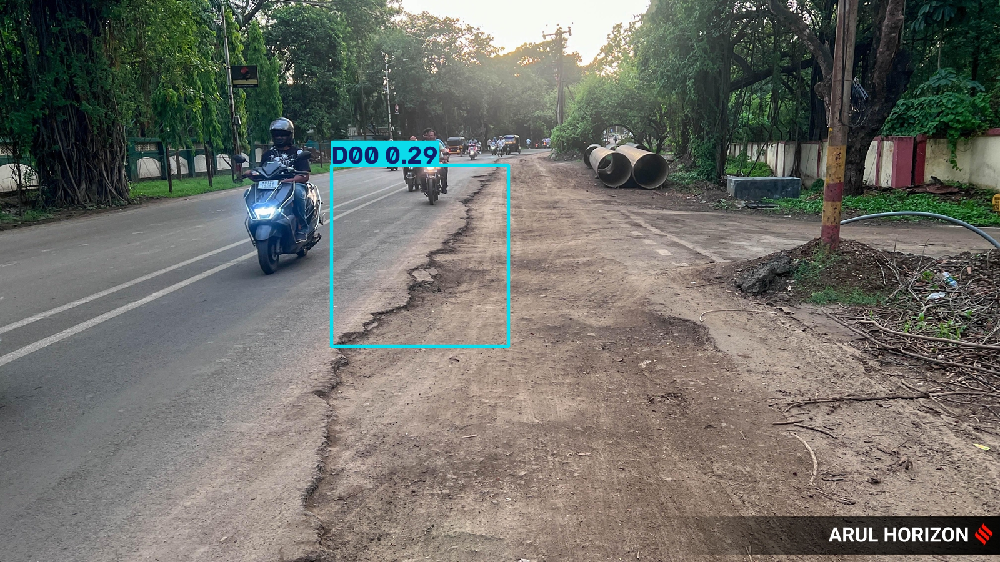

In [21]:
from google.colab import files

uploaded = files.upload()

image_path = list(uploaded.keys())[0]

print("Testing:", image_path)

china_results = china_model.predict(
    source=image_path,
    imgsz=640,
    conf=0.25
)

china_results[0].show()